# Seeded LC vs BCO on Mumford0

This notebook compares LC construction, seeded LC improvement, and BCO variants on `Mumford0` with the same route contract used by the NX-heuristic dataset:

- `N_ROUTES = 10`
- `MIN_ROUTE_LEN = 2`
- `MAX_ROUTE_LEN = 12`

The BCO variants use readable names for the mutation mix, while the low-level BCO API still receives its internal `n_type*` counters.


## 1. Imports


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from torch_geometric.loader import DataLoader

from connectpt.routes_generator.citygraph_dataset import get_dataset_from_config, load_macsa_scenarios
from connectpt.routes_generator.improvement_learning import load_raw_graphs_and_lc_routes, rollout_lc_improvement
from connectpt.routes_generator.utils import get_eval_cfg
from connectpt.routes_generator.eval_route_generator import eval_model
from connectpt.routes_generator.bee_colony import bee_colony
from connectpt.routes_generator.torch_utils import dump_routes, get_batch_tensor_from_routes
from connectpt.routes_generator.transit_time_estimator import RouteGenBatchState
import connectpt.routes_generator.utils as lrnu

# Print wide DataFrames in full (no column / width truncation).
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)


## 2. Paths And Experiment Parameters


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "connectpt").exists() and (candidate / "examples").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root from current working directory")

ROOT_DIR = find_repo_root()
CFG_DIR = ROOT_DIR / "connectpt" / "routes_generator" / "cfg"
BENCHMARK_DIR = ROOT_DIR / "examples" / "data" / "benchmark"
MACSA_DATA_DIR = ROOT_DIR / "examples" / "data" / "MACSA_data"
MODEL_WEIGHTS_PATH = ROOT_DIR / "examples" / "data" / "model_weights" / "inductive_random_graphs_weighted_connectivity.pt"
EDIT_MODEL_WEIGHTS_PATH = ROOT_DIR / "examples" / "route_generator" / "lc_improvement_outputs" / "improvement_lc_improvement_trim.pt"
OUTPUT_ROUTES_DIR = ROOT_DIR / "examples" / "route_generator" / "output_routes"

CITY_NAME = "Mumford0"

N_ROUTES = 10
MIN_ROUTE_LEN = 2
MAX_ROUTE_LEN = 12

LC_SAMPLES = 100
USE_NEURAL_BCO = False
BCO_N_BEES = 10
BCO_N_ITERATIONS = 20
BCO_N_TYPE1_BEES = 5
BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN = False
BCO_EDIT_IGNORE_MAX_ROUTE_LEN = False
BCO_TRIM_IGNORE_MAX_ROUTE_LEN = False
BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN = False
BCO_WORSE_ACCEPT_TEMPERATURE = 0.0
BCO_WORSE_ACCEPT_DECAY = 0.995
BCO_WORSE_ACCEPT_MIN_TEMPERATURE = 0.001
BCO_WORSE_SELECTION_TEMPERATURE = 0.0
BCO_WORSE_SELECTION_DECAY = 0.995
BCO_WORSE_SELECTION_MIN_TEMPERATURE = 0.001
BCO_WORSE_SELECTION_UNIFORM_MIX = 0.05
BCO_WORSE_SELECTION_ELITE_COUNT = 1
# Trim-grace selection: a route-shrinking (trim) mutation is
# force-accepted as a setup move and the bee is shielded from
# cost-based selection for this many population-selection rounds, so a
# follow-up extend can build on the trim. Applied only to the
# worse-accept experiment below.
BCO_TRIM_GRACE_PERIOD = 3

RL_IMPROVEMENT_RUN_NAME = "rl_improvement_only_from_lc_mumford0"
RL_MAX_ROUTE_EDIT_STEPS = None
RL_MAX_TRIM_ACTIONS_PER_ROUTE = 1
RL_FORCE_NONHALT_FIRST_STEP = False
RL_RETURN_BEST_ROUTES = False

DEMAND_TIME_WEIGHT = 0.33
ROUTE_TIME_WEIGHT = 0.33
MEDIAN_CONNECTIVITY_WEIGHT = 0.33

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"CFG_DIR: {CFG_DIR}")
print(f"MODEL_WEIGHTS_PATH exists: {MODEL_WEIGHTS_PATH.exists()}")
print(f"EDIT_MODEL_WEIGHTS_PATH exists: {EDIT_MODEL_WEIGHTS_PATH.exists()}")


ROOT_DIR: D:\PythonProjects\connectpt
CFG_DIR: D:\PythonProjects\connectpt\connectpt\routes_generator\cfg
MODEL_WEIGHTS_PATH exists: True
EDIT_MODEL_WEIGHTS_PATH exists: True


## 3. Load Benchmark Tensors


In [3]:
def load_benchmark_tensors(city_name: str = CITY_NAME) -> dict:
    node_locs = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}Coords.txt", skip_header=1),
        dtype=torch.float32,
    )
    street_adj = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}TravelTimes.txt"),
        dtype=torch.float32,
    ) * 60
    demand = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}Demand.txt"),
        dtype=torch.float32,
    )
    return {
        "node_locs": node_locs,
        "street_adj": street_adj,
        "demand": demand,
    }

input_tensors = load_benchmark_tensors()
print({key: tuple(value.shape) for key, value in input_tensors.items()})


{'node_locs': (30, 2), 'street_adj': (30, 30), 'demand': (30, 30)}


## 4. Helper Functions


In [ ]:
def make_test_dataloader(dataset_cfg):
    dataset = get_dataset_from_config(dataset_cfg, tensors=input_tensors)
    return DataLoader(dataset, batch_size=1)


def make_tensor_dataloader(dataset_cfg, tensors):
    dataset = get_dataset_from_config(dataset_cfg, tensors=tensors)
    return DataLoader(dataset, batch_size=1)


BCO_ROUTE_SELECTION_MODES = {
    "uniform": {
        "label": "uniform random",
        "use_demand_weighted_route_selection": False,
    },
}

MUTATION_TYPES = (
    {"key": "type1", "slug": "heuristic_rebuild", "label": "heuristic rebuild"},
    {"key": "type2", "slug": "local_endpoint_edit", "label": "local endpoint edit"},
    {"key": "type3", "slug": "path_mix_rebuild", "label": "path mix rebuild"},
    {"key": "type4", "slug": "construction_extend", "label": "construction extend"},
    {"key": "type5", "slug": "extend_trim_edit", "label": "extend/trim edit"},
    {"key": "type6", "slug": "trim_only", "label": "trim only"},
    {"key": "type7", "slug": "trim_then_extend", "label": "trim then extend"},
)
MUTATION_TYPE_KEYS = tuple(item["key"] for item in MUTATION_TYPES)
MUTATION_TYPE_SLUGS = {item["key"]: item["slug"] for item in MUTATION_TYPES}
MUTATION_TYPE_LABELS = {item["key"]: item["label"] for item in MUTATION_TYPES}


def mutation_slug(type_name: str) -> str:
    return MUTATION_TYPE_SLUGS[type_name]


def mutation_label(type_name: str) -> str:
    return MUTATION_TYPE_LABELS[type_name]


def route_selection_mode_label(mode_key: str) -> str:
    return BCO_ROUTE_SELECTION_MODES[mode_key]["label"]


def route_selection_mode_suffix(mode_key: str) -> str:
    return mode_key


def safe_run_name(run_name: str) -> str:
    run_name = str(run_name)
    safe_chars = []
    for char in run_name:
        if char.isascii() and (char.isalnum() or char in "._-"):
            safe_chars.append(char)
        else:
            safe_chars.append("_")
    safe = "_".join(part for part in "".join(safe_chars).split("_") if part)
    return safe.strip("._-") or "run"


def build_lc_cfg(
    run_name: str,
    n_routes: int,
    min_route_len: int,
    max_route_len: int,
    demand_time_weight: float = DEMAND_TIME_WEIGHT,
    route_time_weight: float = ROUTE_TIME_WEIGHT,
    median_connectivity_weight: float = MEDIAN_CONNECTIVITY_WEIGHT,
):
    run_name = safe_run_name(run_name)
    params = {
        "dataset_name": "tensor",
        "n_routes": n_routes,
        "min_route_len": min_route_len,
        "max_route_len": max_route_len,
        "demand_time_weight": demand_time_weight,
        "route_time_weight": route_time_weight,
        "median_connectivity_weight": median_connectivity_weight,
        "run_name": run_name,
        "model_weights": str(MODEL_WEIGHTS_PATH),
    }
    cfg = get_eval_cfg(str(CFG_DIR), "eval_model_mumford", params)
    cfg.batch_size = 1
    return cfg


def build_bco_cfg(
    run_name: str,
    n_routes: int,
    min_route_len: int,
    max_route_len: int,
    use_neural_bees: bool = USE_NEURAL_BCO,
    n_bees: int = BCO_N_BEES,
    n_type1_bees: int = BCO_N_TYPE1_BEES,
    n_type2_bees: int | None = None,
    n_type4_bees: int = 0,
    n_type5_bees: int = 0,
    n_type6_bees: int = 0,
    n_type7_bees: int = 0,
    ignore_type4_max_route_len: bool = BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
    ignore_type5_max_route_len: bool = BCO_EDIT_IGNORE_MAX_ROUTE_LEN,
    ignore_type6_max_route_len: bool = BCO_TRIM_IGNORE_MAX_ROUTE_LEN,
    ignore_type7_max_route_len: bool = BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN,
    use_demand_weighted_route_selection: bool = False,
    demand_time_weight: float = DEMAND_TIME_WEIGHT,
    route_time_weight: float = ROUTE_TIME_WEIGHT,
    median_connectivity_weight: float = MEDIAN_CONNECTIVITY_WEIGHT,
    worse_accept_temperature: float = BCO_WORSE_ACCEPT_TEMPERATURE,
    worse_accept_decay: float = BCO_WORSE_ACCEPT_DECAY,
    worse_accept_min_temperature: float = BCO_WORSE_ACCEPT_MIN_TEMPERATURE,
    worse_selection_temperature: float = BCO_WORSE_SELECTION_TEMPERATURE,
    worse_selection_decay: float = BCO_WORSE_SELECTION_DECAY,
    worse_selection_min_temperature: float = BCO_WORSE_SELECTION_MIN_TEMPERATURE,
    worse_selection_uniform_mix: float = BCO_WORSE_SELECTION_UNIFORM_MIX,
    worse_selection_elite_count: int = BCO_WORSE_SELECTION_ELITE_COUNT,
    trim_grace_period: int = 0,
):
    """Build a BCO config.

    User-facing mutation names:
      heuristic_rebuild      - rebuild the chosen route
      local_endpoint_edit    - local extend/shorten by one stop
      path_mix_rebuild       - random path-combiner rebuild
      construction_extend    - one construction-model extension/halt step
      extend_trim_edit       - one edit-model extend/trim/halt step
      trim_only              - one edit-model trim/halt step
      trim_then_extend       - trim/halt, then construction extend/halt
    """
    run_name = safe_run_name(run_name)
    base_cfg_name = "neural_bco_mumford" if use_neural_bees else "bco_mumford"
    effective_type2 = (
        n_bees - n_type1_bees - n_type4_bees - n_type5_bees - n_type6_bees - n_type7_bees
        if n_type2_bees is None
        else n_type2_bees
    )
    overrides = [
        "+eval=mumford0",
        "++eval.dataset.type=tensor",
        f"++eval.n_routes={n_routes}",
        f"++eval.min_route_len={min_route_len}",
        f"++eval.max_route_len={max_route_len}",
        f"++experiment.cost_function.kwargs.demand_time_weight={demand_time_weight}",
        f"++experiment.cost_function.kwargs.route_time_weight={route_time_weight}",
        f"++experiment.cost_function.kwargs.median_connectivity_weight={median_connectivity_weight}",
        f"++run_name={run_name}",
        f"++n_bees={n_bees}",
        f"++n_iterations={BCO_N_ITERATIONS}",
        f"++n_type1_bees={n_type1_bees}",
        f"++n_type2_bees={effective_type2}",
        f"++n_type4_bees={n_type4_bees}",
        f"++n_type5_bees={n_type5_bees}",
        f"++n_type6_bees={n_type6_bees}",
        f"++n_type7_bees={n_type7_bees}",
        f"++ignore_type4_max_route_len={str(ignore_type4_max_route_len).lower()}",
        f"++ignore_type5_max_route_len={str(ignore_type5_max_route_len).lower()}",
        f"++ignore_type6_max_route_len={str(ignore_type6_max_route_len).lower()}",
        f"++ignore_type7_max_route_len={str(ignore_type7_max_route_len).lower()}",
        f"++use_demand_weighted_route_selection={str(use_demand_weighted_route_selection).lower()}",
        f"++worse_accept_temperature={worse_accept_temperature}",
        f"++worse_accept_decay={worse_accept_decay}",
        f"++worse_accept_min_temperature={worse_accept_min_temperature}",
        f"++worse_selection_temperature={worse_selection_temperature}",
        f"++worse_selection_decay={worse_selection_decay}",
        f"++worse_selection_min_temperature={worse_selection_min_temperature}",
        f"++worse_selection_uniform_mix={worse_selection_uniform_mix}",
        f"++worse_selection_elite_count={worse_selection_elite_count}",
        f"++trim_grace_period={trim_grace_period}",
    ]
    if use_neural_bees:
        overrides.append(f"+model.weights='{MODEL_WEIGHTS_PATH}'")
    with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
        cfg = compose(config_name=base_cfg_name, overrides=overrides)
    cfg.batch_size = 1
    n_type3 = (n_bees - n_type1_bees - effective_type2 - n_type4_bees -
               n_type5_bees - n_type6_bees - n_type7_bees)
    route_selection_label = "weighted" if use_demand_weighted_route_selection else "uniform-random"
    print(
        f"[{run_name}] route_selection={route_selection_label} | "
        f"bee split: heuristic_rebuild={n_type1_bees} "
        f"local_endpoint_edit={effective_type2} path_mix_rebuild={n_type3} "
        f"construction_extend={n_type4_bees} extend_trim_edit={n_type5_bees} "
        f"trim_only={n_type6_bees} trim_then_extend={n_type7_bees} "
        f"(total={n_bees})"
    )
    return cfg


def as_route_tensor(routes):
    if isinstance(routes, torch.Tensor):
        return routes.detach().cpu()
    return get_batch_tensor_from_routes(routes).detach().cpu()


def metric_value(metrics, key, default=np.nan):
    if key not in metrics or metrics[key] is None:
        return default
    value = metrics[key]
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu()
        if value.numel() == 0:
            return default
        return float(value.float().mean().item())
    return float(value)


def _expand_batch_value(value, batch_size: int, device):
    if isinstance(value, torch.Tensor):
        value = value.to(device=device, dtype=torch.float32)
    else:
        value = torch.tensor(value, device=device, dtype=torch.float32)
    if value.numel() == 1:
        value = value.expand(batch_size)
    elif value.shape[0] > batch_size:
        value = value[:batch_size]
    return value


def _cost_weight(state, cost_obj, name: str):
    fallback = getattr(cost_obj, name)
    return _expand_batch_value(state.cost_weights.get(name, fallback), state.batch_size, state.device)


def compute_cost_breakdown(dataloader, eval_cfg, cost_obj, routes_tensor, device):
    data = next(iter(dataloader))
    if device is not None and device.type != "cpu":
        data = data.cuda()
    state = RouteGenBatchState(
        data,
        cost_obj,
        eval_cfg.n_routes,
        eval_cfg.min_route_len,
        eval_cfg.max_route_len,
    )
    routes_tensor = as_route_tensor(routes_tensor).to(state.device)
    state.add_new_routes(routes_tensor)

    cho = cost_obj._cost_helper(state)
    demand_time_weight = _cost_weight(state, cost_obj, "demand_time_weight")
    route_time_weight = _cost_weight(state, cost_obj, "route_time_weight")
    median_connectivity_weight = _cost_weight(state, cost_obj, "median_connectivity_weight")
    constraint_weight = _expand_batch_value(
        getattr(cost_obj, "constraint_violation_weight", 0.0),
        state.batch_size,
        state.device,
    )

    time_normalizer = state.drive_times.flatten(1, 2).max(1).values
    n_routes = state.n_routes_to_plan
    served_demand = cho.total_demand - cho.unserved_demand
    demand_component = (
        cho.mean_demand_time * served_demand + cho.unserved_demand * time_normalizer * 2
    ) / cho.total_demand
    route_component = cho.total_route_time
    connectivity_component = cho.median_connectivity_weighted if cost_obj.use_weighted_connectivity else cho.median_connectivity

    demand_component = demand_component / time_normalizer
    route_component = route_component / (time_normalizer * n_routes + 1e-6)
    connectivity_component = connectivity_component / time_normalizer

    demand_term = demand_component * demand_time_weight
    route_term = route_component * route_time_weight
    connectivity_term = connectivity_component * median_connectivity_weight

    frac_uncovered = cho.n_disconnected_demand_edges / state.n_demand_edges
    penalty_component = frac_uncovered + 0.1 * (frac_uncovered > 0)
    if not cost_obj.ignore_stops_oob:
        denom = n_routes * state.min_route_len
        denom = torch.where(denom == 0, torch.ones_like(denom), denom)
        frac_stops_oob = cho.n_stops_oob / denom
        penalty_component = penalty_component + frac_stops_oob + 0.1 * (frac_stops_oob > 0)
    penalty_term = penalty_component * constraint_weight
    cost_sum = demand_term + route_term + connectivity_term + penalty_term

    def mean_cpu(x):
        return x.float().mean().detach().cpu()

    return {
        "cost_demand_component": mean_cpu(demand_component),
        "cost_route_component": mean_cpu(route_component),
        "cost_connectivity_component": mean_cpu(connectivity_component),
        "cost_penalty_component": mean_cpu(penalty_component),
        "cost_demand_term": mean_cpu(demand_term),
        "cost_route_term": mean_cpu(route_term),
        "cost_connectivity_term": mean_cpu(connectivity_term),
        "cost_penalty_term": mean_cpu(penalty_term),
        "cost_sum_check": mean_cpu(cost_sum),
        "cost_demand_weight": mean_cpu(demand_time_weight),
        "cost_route_weight": mean_cpu(route_time_weight),
        "cost_connectivity_weight": mean_cpu(median_connectivity_weight),
        "cost_constraint_weight": mean_cpu(constraint_weight),
    }


def add_cost_breakdown_to_metrics(metrics, dataloader, eval_cfg, cost_obj, routes_tensor, device):
    metrics = dict(metrics)
    metrics.update(compute_cost_breakdown(dataloader, eval_cfg, cost_obj, routes_tensor, device))
    return metrics


def format_cost_terms(metrics):
    return (
        f"cost={metric_value(metrics, 'cost'):.4f} "
        f"[d={metric_value(metrics, 'cost_demand_term'):.3f}, "
        f"r={metric_value(metrics, 'cost_route_term'):.3f}, "
        f"c={metric_value(metrics, 'cost_connectivity_term'):.3f}, "
        f"pen={metric_value(metrics, 'cost_penalty_term'):.3f}]"
    )


def format_absolute_metrics(metrics):
    mc_value = metric_value(metrics, "median_connectivity", default=np.nan)
    mc_part = f", MC={mc_value:.3f}" if np.isfinite(mc_value) else ""
    return (
        f"ATT={metric_value(metrics, 'ATT'):.3f}, "
        f"RTT={metric_value(metrics, 'RTT'):.3f}{mc_part}, "
        f"d_un={metric_value(metrics, '$d_{un}$'):.2f}%"
    )


def format_plot_metrics(metrics):
    return f"{format_cost_terms(metrics)}\n{format_absolute_metrics(metrics)}"


def run_lc(cfg, init_routes=None, revisit_routes=None, *,
           tensors=None, run_name_prefix="lc_"):
    # tensors=None -> Mumford0 dataloader; tensors=<dict> -> explicit
    # tensor dataset (unifies the former run_lc_on_tensors).
    if tensors is None:
        dataloader = make_test_dataloader(cfg.eval.dataset)
    else:
        dataloader = make_tensor_dataloader(cfg.eval.dataset, tensors)
    device, run_name, _, cost_obj, model = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix=run_name_prefix,
        weights_required=True,
    )
    init_cfg = OmegaConf.create({"method": "tensor"}) if init_routes is not None else None
    if hasattr(model, "clear_step_counts_log"):
        model.clear_step_counts_log()
    _, unserved_demand, metrics, routes = eval_model(
        model,
        dataloader,
        cfg.eval,
        cost_obj,
        n_samples=LC_SAMPLES,
        return_routes=True,
        silent=True,
        device=device,
        init_cfg=init_cfg,
        routes_tensor=init_routes,
        revisit_routes_tensor=revisit_routes,
    )
    routes_tensor = as_route_tensor(routes)
    metrics = add_cost_breakdown_to_metrics(metrics, dataloader, cfg.eval, cost_obj, routes_tensor, device)
    step_counts = getattr(model, "route_step_counts_log", [])
    return run_name, metrics, unserved_demand, routes_tensor, list(step_counts)


def build_edit_model(device):
    """Load the trim-capable edit model used by edit/trim BCO mutations."""
    with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
        edit_cfg = compose(
            config_name="ppo_50nodes.yaml",
            overrides=[
                "model=bestsofar_feb2023_trim",
                "model.route_generator.kwargs.serial_halting=True",
                "++run_name=eval_seeded_edit_model",
                "++experiment.logdir=null",
                f"+model.weights='{EDIT_MODEL_WEIGHTS_PATH}'",
            ],
        )
    edit_model = lrnu.build_model_from_cfg(edit_cfg.model, edit_cfg.experiment)
    edit_model.load_state_dict(
        torch.load(EDIT_MODEL_WEIGHTS_PATH, map_location=device)
    )
    edit_model.to(device).eval()
    return edit_model


def run_rl_improvement(
    init_routes,
    run_name: str = RL_IMPROVEMENT_RUN_NAME,
    n_routes: int = N_ROUTES,
    min_route_len: int = MIN_ROUTE_LEN,
    max_route_len: int = MAX_ROUTE_LEN,
    max_route_edit_steps: int | None = RL_MAX_ROUTE_EDIT_STEPS,
    max_trim_actions_per_route: int | None = RL_MAX_TRIM_ACTIONS_PER_ROUTE,
    force_nonhalt_first_step: bool = RL_FORCE_NONHALT_FIRST_STEP,
    return_best_routes: bool = RL_RETURN_BEST_ROUTES,
    *,
    tensors=None,
    weights=None,
):
    """Run the trained edit/RL agent once over all seeded routes, without BCO.

    tensors=None -> Mumford0 dataloader; tensors=<dict> -> explicit tensor
    dataset. weights=<dict with demand/route/connectivity weights> overrides
    the cost-objective weights (used for the objective-weight sweep).
    """
    cfg = build_bco_cfg(
        run_name=run_name,
        n_routes=n_routes,
        min_route_len=min_route_len,
        max_route_len=max_route_len,
        use_neural_bees=False,
        n_type1_bees=0,
        n_type2_bees=0,
        n_type4_bees=0,
        n_type5_bees=0,
        n_type6_bees=0,
        n_type7_bees=0,
        **(weights or {}),
    )

    def _make_loader():
        if tensors is None:
            return make_test_dataloader(cfg.eval.dataset)
        return make_tensor_dataloader(cfg.eval.dataset, tensors)

    dataloader = _make_loader()
    device, resolved_run_name, _, cost_obj, _ = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix="rl_improvement_",
        weights_required=False,
    )
    edit_model = build_edit_model(device)
    graph_batch = next(iter(dataloader))
    if device is not None and device.type != "cpu":
        graph_batch = graph_batch.cuda()
    route_batch = as_route_tensor(init_routes).to(device=device, dtype=torch.long)
    if route_batch.ndim == 2:
        route_batch = route_batch.unsqueeze(0)
    eval_weights = cost_obj.get_weights(device)
    rollout_output = rollout_lc_improvement(
        edit_model,
        cost_obj,
        graph_batch,
        route_batch,
        cfg.eval.min_route_len,
        cfg.eval.max_route_len,
        greedy=True,
        cost_weights=eval_weights,
        force_nonhalt_first_step=force_nonhalt_first_step,
        max_route_edit_steps=max_route_edit_steps,
        max_trim_actions_per_route=max_trim_actions_per_route,
        return_best_routes=return_best_routes,
    )
    final_state = rollout_output[0]
    routes_tensor = as_route_tensor(final_state.routes)

    eval_dataloader = _make_loader()
    output = lrnu.test_method(
        None,
        eval_dataloader,
        cfg.eval,
        OmegaConf.create({"method": "tensor"}),
        cost_obj,
        silent=True,
        device=device,
        return_routes=True,
        routes_tensor=routes_tensor,
    )
    _, _, unserved_demand, metrics, eval_routes = output
    routes_tensor = as_route_tensor(eval_routes)
    metrics = add_cost_breakdown_to_metrics(metrics, eval_dataloader, cfg.eval, cost_obj, routes_tensor, device)
    return resolved_run_name, metrics, unserved_demand, routes_tensor, cfg


def run_bco(cfg, init_routes, mutation_counts_out=None, *,
            tensors=None, run_name_scope=""):
    # tensors=None -> Mumford0 dataloader; tensors=<dict> -> explicit
    # tensor dataset. run_name_scope prefixes the run name so the
    # NX paths can keep their "nx_dataset_" / "dataset_" labels.
    # Unifies the former run_bco / run_bco_on_nx_tensors /
    # run_bco_on_tensors trio.
    if tensors is None:
        dataloader = make_test_dataloader(cfg.eval.dataset)
    else:
        dataloader = make_tensor_dataloader(cfg.eval.dataset, tensors)
    use_neural_bees = cfg.get("neural_bees", False)
    prefix = f"{run_name_scope}"
    prefix += "neural_bco_" if use_neural_bees else "bco_"
    device, run_name, _, cost_obj, bee_model = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix=prefix,
        weights_required=use_neural_bees,
    )
    force_linking_unlinked = cfg.get("force_linking_unlinked", False)
    if not use_neural_bees:
        bee_model = None
    elif bee_model is not None:
        bee_model.force_linking_unlinked = force_linking_unlinked
        bee_model.eval()

    n_type5_bees = int(cfg.get("n_type5_bees", 0))
    n_type6_bees = int(cfg.get("n_type6_bees", 0))
    n_type7_bees = int(cfg.get("n_type7_bees", 0))
    edit_model = build_edit_model(device) if (n_type5_bees > 0 or n_type6_bees > 0 or n_type7_bees > 0) else None
    mutation_counts_out = {} if mutation_counts_out is None else mutation_counts_out

    output = lrnu.test_method(
        bee_colony,
        dataloader,
        cfg.eval,
        OmegaConf.create({"method": "tensor"}),
        cost_obj,
        silent=True,
        device=device,
        return_routes=True,
        routes_tensor=init_routes,
        n_bees=cfg.n_bees,
        n_iterations=cfg.n_iterations,
        n_type1_bees=cfg.get("n_type1_bees", None),
        n_type2_bees=cfg.get("n_type2_bees", None),
        n_type4_bees=cfg.get("n_type4_bees", 0),
        n_type5_bees=n_type5_bees,
        n_type6_bees=n_type6_bees,
        n_type7_bees=n_type7_bees,
        bee_model=bee_model,
        edit_model=edit_model,
        force_linking_unlinked=force_linking_unlinked,
        adjustment_degree_weight=cfg.get("adjustment_degree_weight", 0.0),
        adjustment_degree_gap=cfg.get("adjustment_degree_gap", 0.1),
        adjustment_degree_mode=cfg.get("adjustment_degree_mode", "current"),
        adjustment_degree_objective=cfg.get("adjustment_degree_objective", "raw"),
        adjustment_degree_target=cfg.get("adjustment_degree_target", 0.2),
        ignore_type4_max_route_len=cfg.get("ignore_type4_max_route_len", False),
        ignore_type5_max_route_len=cfg.get("ignore_type5_max_route_len", False),
        ignore_type6_max_route_len=cfg.get("ignore_type6_max_route_len", False),
        ignore_type7_max_route_len=cfg.get("ignore_type7_max_route_len", False),
        use_demand_weighted_route_selection=cfg.get("use_demand_weighted_route_selection", False),
        worse_accept_temperature=cfg.get("worse_accept_temperature", 0.0),
        worse_accept_decay=cfg.get("worse_accept_decay", 0.995),
        worse_accept_min_temperature=cfg.get("worse_accept_min_temperature", 0.001),
        worse_selection_temperature=cfg.get("worse_selection_temperature", 0.0),
        worse_selection_decay=cfg.get("worse_selection_decay", 0.995),
        worse_selection_min_temperature=cfg.get("worse_selection_min_temperature", 0.001),
        worse_selection_uniform_mix=cfg.get("worse_selection_uniform_mix", 0.05),
        worse_selection_elite_count=cfg.get("worse_selection_elite_count", 1),
        trim_grace_period=cfg.get("trim_grace_period", 0),
        mutation_counts_out=mutation_counts_out,
    )
    _, _, unserved_demand, metrics, routes = output
    routes_tensor = as_route_tensor(routes)
    metrics = add_cost_breakdown_to_metrics(metrics, dataloader, cfg.eval, cost_obj, routes_tensor, device)
    return run_name, metrics, unserved_demand, routes_tensor, mutation_counts_out


def summarize_run(label: str, metrics: dict, routes):
    routes = as_route_tensor(routes)
    n_nonempty_routes = int(((routes > -1).sum(dim=-1) > 1).sum().item())
    return {
        "method": label,
        "cost": metric_value(metrics, "cost"),
        "cost_demand_term": metric_value(metrics, "cost_demand_term"),
        "cost_route_term": metric_value(metrics, "cost_route_term"),
        "cost_connectivity_term": metric_value(metrics, "cost_connectivity_term"),
        "cost_penalty_term": metric_value(metrics, "cost_penalty_term"),
        "ATT": metric_value(metrics, "ATT"),
        "RTT": metric_value(metrics, "RTT"),
        "median_connectivity": metric_value(metrics, "median_connectivity"),
        "$d_{un}$": metric_value(metrics, "$d_{un}$"),
        "# disconnected node pairs": metric_value(metrics, "# disconnected node pairs"),
        "# stops out of bounds": metric_value(metrics, "# stops out of bounds"),
        "# routes": n_nonempty_routes,
    }


def mutation_stat_bucket(mutation_stats: dict, bucket: str) -> dict:
    nested = mutation_stats.get(bucket, {}) if mutation_stats else {}
    if bucket == "attempted" and not nested:
        nested = {name: mutation_stats.get(name, 0) for name in MUTATION_TYPE_KEYS} if mutation_stats else {}
    return {name: int(nested.get(name, 0)) for name in MUTATION_TYPE_KEYS}


def selection_stat_bucket(mutation_stats: dict) -> dict:
    nested = mutation_stats.get("selection", {}) if mutation_stats else {}
    return {
        "parent_copies": int(nested.get("parent_copies", 0)),
        "nonbest_parent_copies": int(nested.get("nonbest_parent_copies", 0)),
        "worse_parent_copies": int(nested.get("worse_parent_copies", 0)),
        "trim_grace_forced_accepts": int(nested.get("trim_grace_forced_accepts", 0)),
        "trim_grace_protected": int(nested.get("trim_grace_protected", 0)),
    }


def summarize_mutation_stats(mutation_stats: dict) -> dict:
    return {
        "attempted": {mutation_slug(k): v for k, v in mutation_stat_bucket(mutation_stats, "attempted").items()},
        "accepted": {mutation_slug(k): v for k, v in mutation_stat_bucket(mutation_stats, "accepted").items()},
        "worse_accepted": {mutation_slug(k): v for k, v in mutation_stat_bucket(mutation_stats, "worse_accepted").items()},
        "selection": selection_stat_bucket(mutation_stats),
    }


def plot_mutation_histogram(mutation_stats, title, ax=None):
    """Unified per-mutation-type histogram for one BCO run.

    Shows attempted / accepted / worse-accepted counts per mutation type and
    annotates trim-grace activity in the title when present. ``mutation_stats``
    is either a raw mutation_counts dict from one BCO run or a seed-averaged
    dict from ``aggregate_mutation_stats`` (both work — the buckets are read
    through mutation_stat_bucket / selection_stat_bucket).
    """
    attempted = mutation_stat_bucket(mutation_stats, "attempted")
    accepted = mutation_stat_bucket(mutation_stats, "accepted")
    worse_accepted = mutation_stat_bucket(mutation_stats, "worse_accepted")
    selection = selection_stat_bucket(mutation_stats)
    forced = selection.get("trim_grace_forced_accepts", 0)
    protected = selection.get("trim_grace_protected", 0)

    show = ax is None
    if show:
        fig, ax = plt.subplots(figsize=(6.5, 4))

    labels = list(MUTATION_TYPE_KEYS)
    display_labels = [mutation_label(type_name) for type_name in labels]
    xs = np.arange(len(labels))
    series = [
        ("attempted", attempted, "tab:blue", 0.75),
        ("accepted", accepted, "tab:orange", 0.9),
    ]
    if any(worse_accepted.values()):
        series.append(("worse accepted", worse_accepted, "tab:red", 0.85))

    width = min(0.8 / len(series), 0.32)
    offsets = (np.arange(len(series)) - (len(series) - 1) / 2) * width
    all_vals = []
    bar_groups = []
    for offset, (label, values, color, alpha) in zip(offsets, series):
        vals = [values[type_name] for type_name in labels]
        all_vals.extend(vals)
        bar_groups.append(
            ax.bar(xs + offset, vals, width, color=color, alpha=alpha,
                   label=label)
        )

    ax.set_xticks(xs)
    ax.set_xticklabels(display_labels, rotation=30, ha="right")
    full_title = title
    if forced or protected:
        full_title = (f"{title}\ntrim-grace: forced-accepts={forced:g}, "
                      f"protected={protected:g}")
    ax.set_title(full_title)
    ax.set_ylabel("count")
    ax.legend()

    ymax = max(all_vals + [1])
    for bars in bar_groups:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2,
                    height + ymax * 0.015,
                    f"{height:.0f}",
                    ha="center", va="bottom", fontsize=8)

    if show:
        plt.tight_layout()
        plt.show()


def aggregate_mutation_stats(mutation_counts_list):
    """Seed-average a list of per-run mutation_counts dicts into one
    normalized dict that plot_mutation_histogram can render."""
    runs = [mc for mc in mutation_counts_list if mc]
    n = max(len(runs), 1)
    agg = {"attempted": {}, "accepted": {}, "worse_accepted": {},
           "selection": {}}
    for bucket in ("attempted", "accepted", "worse_accepted"):
        for type_name in MUTATION_TYPE_KEYS:
            agg[bucket][type_name] = sum(
                mutation_stat_bucket(mc, bucket)[type_name]
                for mc in runs) / n
    for key in ("parent_copies", "nonbest_parent_copies",
                "worse_parent_copies", "trim_grace_forced_accepts",
                "trim_grace_protected"):
        agg["selection"][key] = sum(
            selection_stat_bucket(mc).get(key, 0) for mc in runs) / n
    return agg


def plot_sweep_mutation_grid(sweep, title_prefix):
    """Grid of unified mutation histograms for a seed-sweep result.

    Rows = accept experiments, cols = BCO variants; each subplot is the
    seed-averaged plot_mutation_histogram. Works for both the LC-init and
    NX-init sweeps (they share the run_bco_seed_sweep result shape).
    """
    results = sweep["results"]
    accept_experiments = sweep["accept_experiments"]
    n_rows = len(accept_experiments)
    n_cols = len(BCO_VARIANTS)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.7 * n_cols, 4.4 * n_rows),
        squeeze=False,
    )
    for row_idx, accept_cfg in enumerate(accept_experiments):
        accept_key = accept_cfg["key"]
        for col_idx, variant in enumerate(BCO_VARIANTS):
            runs = results.get(accept_key, {}).get(variant["key"], [])
            agg = aggregate_mutation_stats(
                [run["mutation_counts"] for run in runs])
            plot_mutation_histogram(
                agg,
                f"{variant['summary_label']}\n{accept_cfg['label']}",
                ax=axes[row_idx, col_idx],
            )
    fig.suptitle(f"{title_prefix}: mutation attempts vs accepts",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def print_lc_result(run_name: str, metrics: dict, routes, step_counts=None):
    routes_tensor = as_route_tensor(routes)
    print(f"Run name: {run_name}")
    print(format_cost_terms(metrics))
    print(format_absolute_metrics(metrics))
    print(f"Routes shape: {tuple(routes_tensor.shape)}")
    if step_counts is not None:
        print(f"Step counts: {step_counts}")


def print_bco_result(mode_label: str, variant_label: str, run_name: str, metrics: dict, routes, mutation_stats: dict):
    routes_tensor = as_route_tensor(routes)
    n_route_sets = routes_tensor.shape[0] if routes_tensor.ndim >= 3 else 1
    print(f"[{mode_label}] {variant_label}")
    print(f"Run name: {run_name}")
    print(format_cost_terms(metrics))
    print(format_absolute_metrics(metrics))
    print(f"Returned route sets: {n_route_sets}")
    print(f"Mutation stats: {summarize_mutation_stats(mutation_stats)}")
    print()


def route_selection_run_name(base_run_name: str, mode_key: str) -> str:
    return f"{base_run_name}_{route_selection_mode_suffix(mode_key)}"


BCO_N_CONSTRUCTION_BEES = 3
BCO_N_EDIT_BEES = 3
BCO_N_TRIM_BEES = 3
BCO_N_TRIM_EXTEND_BEES = 3


def build_default_bco_variants():
    return [
        {
            "key": "seeded_heuristic",
            "summary_label": "Seeded heuristic BCO (rebuild + local edit)",
            "run_name": "seeded_bco_heuristic_from_lc_mumford0",
            "use_neural_bees": USE_NEURAL_BCO,
            "n_type1_bees": BCO_N_TYPE1_BEES,
            "n_type2_bees": None,
            "n_type4_bees": 0,
            "n_type5_bees": 0,
            "n_type6_bees": 0,
            "n_type7_bees": 0,
        },
        {
            "key": "heuristic_extend_trim_split_5_5",
            "summary_label": "Heuristic rebuild + extend/trim edit BCO (5+5)",
            "run_name": "seeded_bco_heuristic_extend_trim_split_5_5_from_lc_mumford0",
            "use_neural_bees": False,
            "n_type1_bees": BCO_N_TYPE1_BEES,
            "n_type2_bees": 0,
            "n_type4_bees": 0,
            "n_type5_bees": BCO_N_BEES - BCO_N_TYPE1_BEES,
            "n_type6_bees": 0,
            "n_type7_bees": 0,
        },
        # {
        #     "key": "construction_only",
        #     "summary_label": f"Construction-only BCO (all {BCO_N_BEES} bees)",
        #     "run_name": "seeded_bco_construction_only_from_lc_mumford0",
        #     "use_neural_bees": True,
        #     "n_type1_bees": 0,
        #     "n_type2_bees": 0,
        #     "n_type4_bees": BCO_N_BEES,
        #     "n_type5_bees": 0,
        #     "n_type6_bees": 0,
        #     "n_type7_bees": 0,
        # },
        {
            "key": "extend_trim_edit_only",
            "summary_label": f"Extend/trim edit-only BCO (all {BCO_N_BEES} bees)",
            "run_name": "seeded_bco_extend_trim_edit_only_from_lc_mumford0",
            "use_neural_bees": False,
            "n_type1_bees": 0,
            "n_type2_bees": 0,
            "n_type4_bees": 0,
            "n_type5_bees": BCO_N_BEES,
            "n_type6_bees": 0,
            "n_type7_bees": 0,
        },
        {
            "key": "trim_then_extend_only",
            "summary_label": f"Trim-then-extend BCO (all {BCO_N_BEES} bees)",
            "run_name": "seeded_bco_trim_then_extend_only_from_lc_mumford0",
            "use_neural_bees": True,
            "n_type1_bees": 0,
            "n_type2_bees": 0,
            "n_type4_bees": 0,
            "n_type5_bees": 0,
            "n_type6_bees": 0,
            "n_type7_bees": BCO_N_BEES,
        },
        # {
        #     "key": "construction_trim_split_5_5",
        #     "summary_label": "Construction + trim BCO (5+5)",
        #     "run_name": "seeded_bco_construction_trim_split_5_5_from_lc_mumford0",
        #     "use_neural_bees": True,
        #     "n_type1_bees": 0,
        #     "n_type2_bees": 0,
        #     "n_type4_bees": 5,
        #     "n_type5_bees": 0,
        #     "n_type6_bees": 5,
        #     "n_type7_bees": 0,
        # },
        # {
        #     "key": "construction_trim_split_8_2",
        #     "summary_label": "Construction + trim BCO (8+2)",
        #     "run_name": "seeded_bco_construction_trim_split_8_2_from_lc_mumford0",
        #     "use_neural_bees": True,
        #     "n_type1_bees": 0,
        #     "n_type2_bees": 0,
        #     "n_type4_bees": 8,
        #     "n_type5_bees": 0,
        #     "n_type6_bees": 2,
        #     "n_type7_bees": 0,
        # },
    ]


BCO_VARIANTS = build_default_bco_variants()

DEFAULT_BCO_PASSES_PER_IT = 5
DEFAULT_BCO_MOD_STEPS_PER_PASS = 2
MUTATION_ATTEMPTS_PER_BEE = (
    BCO_N_ITERATIONS * DEFAULT_BCO_PASSES_PER_IT * DEFAULT_BCO_MOD_STEPS_PER_PASS
)
DEFAULT_SEED_SWEEP_CONSTRUCTION_BEES = BCO_N_CONSTRUCTION_BEES


def target_attempts_to_bees(target_attempts: int, attempts_per_bee: int = MUTATION_ATTEMPTS_PER_BEE) -> int:
    import math

    lower = max(1, target_attempts // attempts_per_bee)
    upper = max(1, math.ceil(target_attempts / attempts_per_bee))
    candidates = sorted({lower, upper})
    return min(
        candidates,
        key=lambda bee_count: (
            abs(bee_count * attempts_per_bee - target_attempts),
            bee_count,
        ),
    )


def run_lc_base():
    cfg = build_lc_cfg(
        run_name="lc_base_mumford0_10r_len12",
        n_routes=N_ROUTES,
        min_route_len=MIN_ROUTE_LEN,
        max_route_len=MAX_ROUTE_LEN,
    )
    run_name, metrics, unserved, routes, step_counts = run_lc(cfg)
    dump_routes(run_name, routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)
    return {
        "cfg": cfg,
        "run_name": run_name,
        "metrics": metrics,
        "unserved_demand": unserved,
        "routes": routes,
        "step_counts": step_counts,
    }


def run_lc_seeded(seed_routes):
    cfg = build_lc_cfg(
        run_name="lc_seeded_second_pass_mumford0_10r_len12",
        n_routes=N_ROUTES,
        min_route_len=MIN_ROUTE_LEN,
        max_route_len=MAX_ROUTE_LEN,
    )
    run_name, metrics, unserved, routes, step_counts = run_lc(
        cfg,
        revisit_routes=seed_routes,
    )
    dump_routes(run_name, routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)
    return {
        "cfg": cfg,
        "run_name": run_name,
        "metrics": metrics,
        "unserved_demand": unserved,
        "routes": routes,
        "step_counts": step_counts,
    }


def bco_variant_type2_bees(variant: dict, n_bees: int = BCO_N_BEES) -> int:
    if variant["n_type2_bees"] is not None:
        return variant["n_type2_bees"]
    return (
        n_bees
        - variant["n_type1_bees"]
        - variant["n_type4_bees"]
        - variant.get("n_type5_bees", 0)
        - variant.get("n_type6_bees", 0)
        - variant.get("n_type7_bees", 0)
    )


def run_bco_experiment_results(init_routes):
    results = {}
    for mode_key, mode_cfg in BCO_ROUTE_SELECTION_MODES.items():
        mode_results = {}
        for variant in BCO_VARIANTS:
            cfg = build_bco_cfg(
                run_name=route_selection_run_name(variant["run_name"], mode_key),
                n_routes=N_ROUTES,
                min_route_len=MIN_ROUTE_LEN,
                max_route_len=MAX_ROUTE_LEN,
                use_neural_bees=variant["use_neural_bees"],
                n_type1_bees=variant["n_type1_bees"],
                n_type2_bees=variant["n_type2_bees"],
                n_type4_bees=variant["n_type4_bees"],
                n_type5_bees=variant.get("n_type5_bees", 0),
                n_type6_bees=variant.get("n_type6_bees", 0),
                n_type7_bees=variant.get("n_type7_bees", 0),
                ignore_type4_max_route_len=BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
                ignore_type5_max_route_len=BCO_EDIT_IGNORE_MAX_ROUTE_LEN,
                ignore_type6_max_route_len=BCO_TRIM_IGNORE_MAX_ROUTE_LEN,
                ignore_type7_max_route_len=BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN,
                use_demand_weighted_route_selection=mode_cfg["use_demand_weighted_route_selection"],
            )
            mutation_counts = {}
            run_name, metrics, unserved_demand, routes, mutation_counts = run_bco(
                cfg,
                init_routes=init_routes,
                mutation_counts_out=mutation_counts,
            )
            dump_routes(run_name, routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)
            mode_results[variant["key"]] = {
                "mode_key": mode_key,
                "mode_label": mode_cfg["label"],
                "variant_key": variant["key"],
                "variant_label": variant["summary_label"],
                "n_type1_bees": variant["n_type1_bees"],
                "n_type2_bees": variant["n_type2_bees"],
                "n_type4_bees": variant["n_type4_bees"],
                "n_type5_bees": variant.get("n_type5_bees", 0),
                "n_type6_bees": variant.get("n_type6_bees", 0),
                "n_type7_bees": variant.get("n_type7_bees", 0),
                "run_name": run_name,
                "metrics": metrics,
                "unserved_demand": unserved_demand,
                "routes": routes,
                "routes_tensor": routes,
                "mutation_counts": mutation_counts,
            }
        results[mode_key] = mode_results
    return results


def run_seed_sweep(
    init_routes,
    mode_key="uniform",
    seeds=None,
    target_heuristic_rebuild_attempts=1000,
    target_local_endpoint_edit_attempts=1000,
    construction_bees=None,
):
    if seeds is None:
        seeds = list(range(1))
    if construction_bees is None:
        construction_bees = DEFAULT_SEED_SWEEP_CONSTRUCTION_BEES

    n_type1_bees = target_attempts_to_bees(target_heuristic_rebuild_attempts)
    n_type2_bees = target_attempts_to_bees(target_local_endpoint_edit_attempts)
    n_bees = n_type1_bees + n_type2_bees + construction_bees
    mode_cfg = BCO_ROUTE_SELECTION_MODES[mode_key]

    rows = []
    results = {}
    for seed in [int(seed) for seed in seeds]:
        cfg = build_bco_cfg(
            run_name=route_selection_run_name(
                f"seeded_bco_seed_sweep_rebuild_{target_heuristic_rebuild_attempts}_local_{target_local_endpoint_edit_attempts}_seed{seed}",
                mode_key,
            ),
            n_routes=N_ROUTES,
            min_route_len=MIN_ROUTE_LEN,
            max_route_len=MAX_ROUTE_LEN,
            use_neural_bees=True,
            n_bees=n_bees,
            n_type1_bees=n_type1_bees,
            n_type2_bees=n_type2_bees,
            n_type4_bees=construction_bees,
            ignore_type4_max_route_len=BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
            use_demand_weighted_route_selection=mode_cfg["use_demand_weighted_route_selection"],
        )
        cfg.experiment.seed = seed
        run_name, metrics, unserved_demand, routes, mutation_stats = run_bco(
            cfg,
            init_routes,
        )
        attempted = mutation_stat_bucket(mutation_stats, "attempted")
        accepted = mutation_stat_bucket(mutation_stats, "accepted")
        row = summarize_run(
            f"seed={seed} [{mode_cfg['label']}]",
            metrics,
            routes,
        )
        row.update({
            "seed": seed,
            "route_selection": mode_cfg["label"],
            "target_heuristic_rebuild_attempts": target_heuristic_rebuild_attempts,
            "target_local_endpoint_edit_attempts": target_local_endpoint_edit_attempts,
            "heuristic_rebuild_bees": n_type1_bees,
            "local_endpoint_edit_bees": n_type2_bees,
            "construction_extend_bees": construction_bees,
            "total_bees": n_bees,
            "attempted_heuristic_rebuild": attempted["type1"],
            "attempted_local_endpoint_edit": attempted["type2"],
            "attempted_construction_extend": attempted["type4"],
            "accepted_heuristic_rebuild": accepted["type1"],
            "accepted_local_endpoint_edit": accepted["type2"],
            "accepted_path_mix_rebuild": accepted["type3"],
            "accepted_construction_extend": accepted["type4"],
            "accepted_total": sum(accepted.values()),
        })
        rows.append(row)
        results[seed] = {
            "run_name": run_name,
            "metrics": metrics,
            "unserved_demand": unserved_demand,
            "routes": routes,
            "routes_tensor": routes,
            "mutation_stats": mutation_stats,
        }

    df = pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)
    summary_cols = [
        "cost",
        "cost_demand_term",
        "cost_route_term",
        "cost_connectivity_term",
        "cost_penalty_term",
        "ATT",
        "RTT",
        "$d_{un}$",
        "# routes",
        "accepted_heuristic_rebuild",
        "accepted_local_endpoint_edit",
        "accepted_path_mix_rebuild",
        "accepted_construction_extend",
        "accepted_total",
    ]
    summary_df = pd.DataFrame({
        "mean": df[summary_cols].mean(),
        "std": df[summary_cols].std(ddof=0),
        "min": df[summary_cols].min(),
        "max": df[summary_cols].max(),
    }).round(4)
    return {
        "mode_key": mode_key,
        "mode_label": mode_cfg["label"],
        "seeds": list(seeds),
        "target_heuristic_rebuild_attempts": target_heuristic_rebuild_attempts,
        "target_local_endpoint_edit_attempts": target_local_endpoint_edit_attempts,
        "construction_bees": construction_bees,
        "n_type1_bees": n_type1_bees,
        "n_type2_bees": n_type2_bees,
        "n_bees": n_bees,
        "rows": rows,
        "results": results,
        "df": df,
        "summary_df": summary_df,
    }


BCO_VARIANTS


[{'key': 'seeded_heuristic',
  'summary_label': 'Seeded heuristic BCO (rebuild + local edit)',
  'run_name': 'seeded_bco_heuristic_from_lc_mumford0',
  'use_neural_bees': False,
  'n_type1_bees': 5,
  'n_type2_bees': None,
  'n_type4_bees': 0,
  'n_type5_bees': 0,
  'n_type6_bees': 0,
  'n_type7_bees': 0}]

## 5. Baseline LC On Mumford0


In [5]:
base_result = run_lc_base()

cfg_lc_base = base_result["cfg"]
lc_base_run_name = base_result["run_name"]
lc_base_metrics = base_result["metrics"]
lc_base_unserved = base_result["unserved_demand"]
lc_base_routes = base_result["routes"]
lc_base_step_counts = base_result["step_counts"]

print_lc_result(lc_base_run_name, lc_base_metrics, lc_base_routes, lc_base_step_counts)
lc_base_routes


Run name: lc_lc_base_mumford0_10r_len12
cost=0.7575 [d=0.280, r=0.383, c=0.094, pen=0.000]
ATT=22.089, RTT=302.000, MC=16.200, d_un=3.72%
Routes shape: (1, 10, 7)
Step counts: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


tensor([[[29, 27, 16, 28,  0, 12,  8],
         [26,  0, 17, 11,  3,  9, -1],
         [ 5,  6, 16,  7, 14, 23, -1],
         [18,  0, 25,  7,  4, -1, -1],
         [22,  0, 13,  6, 10, -1, -1],
         [15, 10,  7, 20, -1, -1, -1],
         [ 2,  7, 24, -1, -1, -1, -1],
         [ 9,  1, 24, -1, -1, -1, -1],
         [21,  2, 29, -1, -1, -1, -1],
         [19, 12, -1, -1, -1, -1, -1]]])

## 6. Seeded LC Revisit Of All Base Routes With One More Total Route And Larger Max Route Length


In [6]:
seeded_result = run_lc_seeded(lc_base_routes)

cfg_lc_seeded = seeded_result["cfg"]
lc_seeded_run_name = seeded_result["run_name"]
lc_seeded_metrics = seeded_result["metrics"]
lc_seeded_unserved = seeded_result["unserved_demand"]
lc_seeded_routes = seeded_result["routes"]
lc_seeded_step_counts = seeded_result["step_counts"]

print_lc_result(lc_seeded_run_name, lc_seeded_metrics, lc_seeded_routes)
lc_seeded_routes

(
    rl_improvement_run_name,
    rl_improvement_metrics,
    rl_improvement_unserved,
    rl_improvement_routes,
    rl_improvement_cfg,
) = run_rl_improvement(lc_base_routes)

print_lc_result(rl_improvement_run_name, rl_improvement_metrics, rl_improvement_routes)
rl_improvement_routes


Run name: lc_lc_seeded_second_pass_mumford0_10r_len12
cost=0.7575 [d=0.280, r=0.383, c=0.094, pen=0.000]
ATT=22.089, RTT=302.000, MC=16.200, d_un=3.72%
Routes shape: (1, 10, 7)
[rl_improvement_only_from_lc_mumford0] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=10 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
Run name: rl_improvement_rl_improvement_only_from_lc_mumford0
cost=0.7575 [d=0.280, r=0.383, c=0.094, pen=0.000]
ATT=22.089, RTT=302.000, MC=16.200, d_un=3.72%
Routes shape: (1, 10, 7)


tensor([[[29, 27, 16, 28,  0, 12,  8],
         [26,  0, 17, 11,  3,  9, -1],
         [ 5,  6, 16,  7, 14, 23, -1],
         [18,  0, 25,  7,  4, -1, -1],
         [22,  0, 13,  6, 10, -1, -1],
         [15, 10,  7, 20, -1, -1, -1],
         [ 2,  7, 24, -1, -1, -1, -1],
         [ 9,  1, 24, -1, -1, -1, -1],
         [21,  2, 29, -1, -1, -1, -1],
         [19, 12, -1, -1, -1, -1, -1]]])

## 7. Seeded BCO Experiments With Uniform Route Selection

Each BCO variant is run once with `uniform random` route-slot selection.


### Experiment Matrix

For uniform route-slot selection, we run:

- seeded heuristic BCO: `heuristic_rebuild + local_endpoint_edit`
- `construction_only`: construction model extend/halt only
- `extend_trim_edit_only`: LC-improvement edit model with extend, trim-start, trim-end, halt
- `trim_then_extend_only`: trim/halt followed by construction extend/halt
- `construction_trim_split_5_5`: construction + trim in a `5+5` bee split
- `construction_trim_split_8_2`: construction + trim in an `8+2` bee split

All neural route-editing variants edit the selected route while the other route slots remain visible as context.

| Variant | Internal BCO mutation | Model used | One mutation can |
|---|---|---|---|
| `seeded_heuristic` | `type1 + type2` | classic BCO heuristics | rebuild selected routes and make random local endpoint edits |
| `construction_only` | `type4` | construction / route-generation model | extend the selected route or halt |
| `extend_trim_edit_only` | `type5` | trim-capable LC-improvement edit model | extend, trim the start, trim the end, or halt |
| `trim_only` | `type6` | trim-capable LC-improvement edit model | trim the start, trim the end, or halt |
| `trim_then_extend_only` | `type7` | edit model + construction model | trim or halt, then extend or halt before scoring |


In [7]:
BCO_VARIANTS = build_default_bco_variants()
BCO_VARIANTS


[{'key': 'seeded_heuristic',
  'summary_label': 'Seeded heuristic BCO (rebuild + local edit)',
  'run_name': 'seeded_bco_heuristic_from_lc_mumford0',
  'use_neural_bees': False,
  'n_type1_bees': 5,
  'n_type2_bees': None,
  'n_type4_bees': 0,
  'n_type5_bees': 0,
  'n_type6_bees': 0,
  'n_type7_bees': 0}]

In [8]:
RUN_SINGLE_BCO_EXPERIMENTS = False

if RUN_SINGLE_BCO_EXPERIMENTS:
    bco_experiment_results = run_bco_experiment_results(init_routes=lc_base_routes)
    uniform_bco_results = bco_experiment_results["uniform"]

    for variant in BCO_VARIANTS:
        result = uniform_bco_results[variant["key"]]
        print_bco_result(
            route_selection_mode_label("uniform"),
            variant["summary_label"],
            result["run_name"],
            result["metrics"],
            result["routes_tensor"],
            result["mutation_counts"],
        )
else:
    print("Skipping separate BCO run; downstream tables use worse_accept_seed_sweep results.")


[seeded_bco_heuristic_from_lc_mumford0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[uniform random] Seeded heuristic BCO (rebuild + local edit)
Run name: bco_seeded_bco_heuristic_from_lc_mumford0_uniform
cost=0.7136 [d=0.289, r=0.327, c=0.097, pen=0.000]
ATT=22.797, RTT=258.000, MC=17.067, d_un=7.50%
Returned route sets: 1
Mutation stats: {'attempted': {'heuristic_rebuild': 1000, 'local_endpoint_edit': 1000, 'path_mix_rebuild': 0, 'construction_extend': 0, 'extend_trim_edit': 0, 'trim_only': 0, 'trim_then_extend': 0}, 'accepted': {'heuristic_rebuild': 1, 'local_endpoint_edit': 10, 'path_mix_rebuild': 0, 'construction_extend': 0, 'extend_trim_edit': 0, 'trim_only': 0, 'trim_then_extend': 0}, 'worse_accepted': {'heuristic_rebuild': 0, 'local_endpoint_edit': 0, 'path_mix_rebuild': 0, 'construction_extend': 0, 'extend_trim_edit': 0, 'trim_

## 8. Worse Acceptance Seed Sweep

This section compares the same readable BCO variants with soft worse acceptance disabled and enabled. Each variant is run with 10 seeds, then metrics, cost-function terms, and mutation statistics are averaged by variant and acceptance mode.


In [9]:
from IPython.display import display

WORSE_ACCEPT_SEEDS = list(range(1))
WORSE_ACCEPT_ON_TEMPERATURE = 2
WORSE_SELECTION_ON_TEMPERATURE = 2
WORSE_ACCEPT_DUMP_ROUTES = False
REUSE_EXISTING_SWEEP_RESULTS = True

WORSE_ACCEPT_EXPERIMENTS = [
    {
        "key": "without_worse",
        "label": "without worse acceptance",
        "temperature": 0.0,
        "decay": BCO_WORSE_ACCEPT_DECAY,
        "min_temperature": BCO_WORSE_ACCEPT_MIN_TEMPERATURE,
        "selection_temperature": 0.0,
        "selection_decay": BCO_WORSE_SELECTION_DECAY,
        "selection_min_temperature": BCO_WORSE_SELECTION_MIN_TEMPERATURE,
        "selection_uniform_mix": BCO_WORSE_SELECTION_UNIFORM_MIX,
        "selection_elite_count": BCO_WORSE_SELECTION_ELITE_COUNT,
        "trim_grace_period": 0,
    },
    {
        "key": "with_worse",
        "label": f"with worse acceptance + soft selection (T0={WORSE_ACCEPT_ON_TEMPERATURE})",
        "temperature": WORSE_ACCEPT_ON_TEMPERATURE,
        "decay": BCO_WORSE_ACCEPT_DECAY,
        "min_temperature": BCO_WORSE_ACCEPT_MIN_TEMPERATURE,
        "selection_temperature": WORSE_SELECTION_ON_TEMPERATURE,
        "selection_decay": BCO_WORSE_SELECTION_DECAY,
        "selection_min_temperature": BCO_WORSE_SELECTION_MIN_TEMPERATURE,
        "selection_uniform_mix": BCO_WORSE_SELECTION_UNIFORM_MIX,
        "selection_elite_count": BCO_WORSE_SELECTION_ELITE_COUNT,
        "trim_grace_period": BCO_TRIM_GRACE_PERIOD,
    },
]


def run_worse_accept_seed_sweep(seeds=None, accept_experiments=None, mode_key="uniform"):
    if seeds is None:
        seeds = WORSE_ACCEPT_SEEDS
    if accept_experiments is None:
        accept_experiments = WORSE_ACCEPT_EXPERIMENTS

    mode_cfg = BCO_ROUTE_SELECTION_MODES[mode_key]
    rows = []
    results = {}
    total_runs = len(accept_experiments) * len(BCO_VARIANTS) * len(seeds)
    run_idx = 0

    for accept_cfg in accept_experiments:
        accept_key = accept_cfg["key"]
        results[accept_key] = {}
        for variant in BCO_VARIANTS:
            variant_results = []
            for seed in seeds:
                run_idx += 1
                print(
                    f"[{run_idx}/{total_runs}] {accept_key} | "
                    f"{variant['key']} | seed={seed}"
                )
                cfg = build_bco_cfg(
                    run_name=route_selection_run_name(
                        f"{variant['run_name']}_{accept_key}_seed{seed}",
                        mode_key,
                    ),
                    n_routes=N_ROUTES,
                    min_route_len=MIN_ROUTE_LEN,
                    max_route_len=MAX_ROUTE_LEN,
                    use_neural_bees=variant["use_neural_bees"],
                    n_type1_bees=variant["n_type1_bees"],
                    n_type2_bees=variant["n_type2_bees"],
                    n_type4_bees=variant["n_type4_bees"],
                    n_type5_bees=variant.get("n_type5_bees", 0),
                    n_type6_bees=variant.get("n_type6_bees", 0),
                    n_type7_bees=variant.get("n_type7_bees", 0),
                    ignore_type4_max_route_len=BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
                    ignore_type5_max_route_len=BCO_EDIT_IGNORE_MAX_ROUTE_LEN,
                    ignore_type6_max_route_len=BCO_TRIM_IGNORE_MAX_ROUTE_LEN,
                    ignore_type7_max_route_len=BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN,
                    use_demand_weighted_route_selection=mode_cfg["use_demand_weighted_route_selection"],
                    worse_accept_temperature=accept_cfg["temperature"],
                    worse_accept_decay=accept_cfg["decay"],
                    worse_accept_min_temperature=accept_cfg["min_temperature"],
                    worse_selection_temperature=accept_cfg["selection_temperature"],
                    worse_selection_decay=accept_cfg["selection_decay"],
                    worse_selection_min_temperature=accept_cfg["selection_min_temperature"],
                    worse_selection_uniform_mix=accept_cfg["selection_uniform_mix"],
                    worse_selection_elite_count=accept_cfg["selection_elite_count"],
                    trim_grace_period=accept_cfg.get("trim_grace_period", 0),
                )
                cfg.experiment.seed = int(seed)

                mutation_counts = {}
                run_name, metrics, unserved_demand, routes, mutation_counts = run_bco(
                    cfg,
                    init_routes=lc_base_routes,
                    mutation_counts_out=mutation_counts,
                )
                if WORSE_ACCEPT_DUMP_ROUTES:
                    dump_routes(run_name, routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

                attempted = mutation_stat_bucket(mutation_counts, "attempted")
                accepted = mutation_stat_bucket(mutation_counts, "accepted")
                worse_accepted = mutation_stat_bucket(mutation_counts, "worse_accepted")
                selection_stats = selection_stat_bucket(mutation_counts)
                row = summarize_run(
                    f"{variant['summary_label']} [{accept_cfg['label']}, seed={seed}]",
                    metrics,
                    routes,
                )
                row.update({
                    "accept_key": accept_key,
                    "accept_mode": accept_cfg["label"],
                    "worse_accept_temperature": accept_cfg["temperature"],
                    "worse_accept_decay": accept_cfg["decay"],
                    "worse_accept_min_temperature": accept_cfg["min_temperature"],
                    "worse_selection_temperature": accept_cfg["selection_temperature"],
                    "worse_selection_decay": accept_cfg["selection_decay"],
                    "worse_selection_min_temperature": accept_cfg["selection_min_temperature"],
                    "worse_selection_uniform_mix": accept_cfg["selection_uniform_mix"],
                    "worse_selection_elite_count": accept_cfg["selection_elite_count"],
                    "seed": int(seed),
                    "route_selection": mode_cfg["label"],
                    "variant_key": variant["key"],
                    "variant": variant["summary_label"],
                    "heuristic_rebuild_bees": variant["n_type1_bees"],
                    "local_endpoint_edit_bees": bco_variant_type2_bees(variant),
                    "construction_extend_bees": variant["n_type4_bees"],
                    "extend_trim_edit_bees": variant.get("n_type5_bees", 0),
                    "trim_only_bees": variant.get("n_type6_bees", 0),
                    "trim_then_extend_bees": variant.get("n_type7_bees", 0),
                    "attempted_total": sum(attempted.values()),
                    "accepted_total": sum(accepted.values()),
                    "worse_accepted_total": sum(worse_accepted.values()),
                    "selection_parent_copies": selection_stats["parent_copies"],
                    "selection_nonbest_parent_copies": selection_stats["nonbest_parent_copies"],
                    "selection_worse_parent_copies": selection_stats["worse_parent_copies"],
                })
                for type_name in MUTATION_TYPE_KEYS:
                    slug = mutation_slug(type_name)
                    row[f"attempted_{slug}"] = attempted[type_name]
                    row[f"accepted_{slug}"] = accepted[type_name]
                    row[f"worse_accepted_{slug}"] = worse_accepted[type_name]
                rows.append(row)
                variant_results.append({
                    "seed": int(seed),
                    "run_name": run_name,
                    "metrics": metrics,
                    "unserved_demand": unserved_demand,
                    "routes": routes,
                    "routes_tensor": routes,
                    "mutation_counts": mutation_counts,
                })
            results[accept_key][variant["key"]] = variant_results

    rows_df = pd.DataFrame(rows)
    return {
        "rows_df": rows_df,
        "results": results,
        "seeds": list(seeds),
        "accept_experiments": accept_experiments,
        "mode_key": mode_key,
        "mode_label": mode_cfg["label"],
    }


def summarize_worse_accept_seed_sweep(rows_df: pd.DataFrame):
    """Seed-average a worse-accept / NX seed-sweep into a comparison table.

    summary_df carries the same metric columns as the cell-27
    comparison_rows table, each as mean_<metric> + std_<metric> over seeds
    (no selection / accepted-total counters — those live in the histograms).
    comparison_df pairs the with_worse vs without_worse means side by side.
    """
    group_cols = ["variant_key", "variant", "accept_key", "accept_mode"]
    metric_cols = [
        "cost", "cost_demand_term", "cost_route_term",
        "cost_connectivity_term", "cost_penalty_term", "ATT", "RTT",
        "median_connectivity", "$d_{un}$", "# disconnected node pairs",
        "# stops out of bounds", "# routes",
    ]
    grouped = rows_df.groupby(group_cols, sort=False)
    stats = grouped[metric_cols].agg(["mean", "std"])
    stats.columns = [f"{stat}_{col}" for col, stat in stats.columns]
    n_seeds = grouped["seed"].nunique().rename("n_seeds")
    summary_df = stats.join(n_seeds).reset_index()

    without_df = summary_df[summary_df["accept_key"] == "without_worse"]
    with_df = summary_df[summary_df["accept_key"] == "with_worse"]
    comparison_df = with_df.merge(
        without_df,
        on=["variant_key", "variant"],
        suffixes=("_with_worse", "_without_worse"),
    )
    keep = ["variant_key", "variant"]
    for col in metric_cols:
        keep += [f"mean_{col}_without_worse", f"mean_{col}_with_worse"]
    comparison_df = comparison_df[keep].copy()
    for col in ["cost", "ATT", "RTT"]:
        comparison_df[f"delta_{col}_with_minus_without"] = (
            comparison_df[f"mean_{col}_with_worse"]
            - comparison_df[f"mean_{col}_without_worse"]
        )
    return summary_df, comparison_df


def bco_experiment_results_from_seed_sweep(
    sweep_results: dict,
    accept_key: str = "without_worse",
    seed: int | None = None,
):
    """Recreate the old bco_experiment_results shape from one seed sweep.

    This keeps all downstream tables/plots working from the sweep as the
    single source of truth, without rerunning BCO variants separately.
    """
    if seed is None:
        seed = int(sweep_results["seeds"][0])

    mode_key = sweep_results.get("mode_key", "uniform")
    mode_label = sweep_results.get("mode_label", route_selection_mode_label(mode_key))
    mode_results = {}
    for variant in BCO_VARIANTS:
        variant_runs = sweep_results["results"][accept_key][variant["key"]]
        result = next(
            (run for run in variant_runs if int(run["seed"]) == int(seed)),
            variant_runs[0],
        )
        mode_results[variant["key"]] = {
            "mode_key": mode_key,
            "mode_label": mode_label,
            "variant_key": variant["key"],
            "variant_label": variant["summary_label"],
            "n_type1_bees": variant["n_type1_bees"],
            "n_type2_bees": variant["n_type2_bees"],
            "n_type4_bees": variant["n_type4_bees"],
            "n_type5_bees": variant.get("n_type5_bees", 0),
            "n_type6_bees": variant.get("n_type6_bees", 0),
            "n_type7_bees": variant.get("n_type7_bees", 0),
            "run_name": result["run_name"],
            "metrics": result["metrics"],
            "unserved_demand": result["unserved_demand"],
            "routes": result["routes"],
            "routes_tensor": result["routes_tensor"],
            "mutation_counts": result["mutation_counts"],
            "source_accept_key": accept_key,
            "source_seed": int(result["seed"]),
        }
    return {mode_key: mode_results}

if REUSE_EXISTING_SWEEP_RESULTS and "worse_accept_seed_sweep" in globals():
    print("Reusing existing worse_accept_seed_sweep; set REUSE_EXISTING_SWEEP_RESULTS=False to rerun BCO.")
else:
    worse_accept_seed_sweep = run_worse_accept_seed_sweep()
worse_accept_rows_df = worse_accept_seed_sweep["rows_df"]
worse_accept_summary_df, worse_accept_comparison_df = summarize_worse_accept_seed_sweep(
    worse_accept_rows_df
)
bco_experiment_results = bco_experiment_results_from_seed_sweep(
    worse_accept_seed_sweep,
    accept_key="without_worse",
)
uniform_bco_results = bco_experiment_results["uniform"]




[1/2] without_worse | seeded_heuristic | seed=0
[seeded_bco_heuristic_from_lc_mumford0_without_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[2/2] with_worse | seeded_heuristic | seed=0
[seeded_bco_heuristic_from_lc_mumford0_with_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)


In [10]:
display(worse_accept_summary_df.round(4))
display(worse_accept_comparison_df.round(4))

,variant_key,variant,accept_key,accept_mode,mean_cost,std_cost,mean_cost_demand_term,std_cost_demand_term,mean_cost_route_term,std_cost_route_term,mean_cost_connectivity_term,std_cost_connectivity_term,mean_cost_penalty_term,std_cost_penalty_term,mean_ATT,std_ATT,mean_RTT,std_RTT,mean_median_connectivity,std_median_connectivity,mean_$d_{un}$,std_$d_{un}$,mean_# disconnected node pairs,std_# disconnected node pairs,mean_# stops out of bounds,std_# stops out of bounds,mean_# routes,std_# routes,n_seeds
0,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),without_worse,without worse acceptance,0.7136,NaN,0.2893,NaN,0.3275,NaN,0.0968,NaN,0.0,NaN,22.7968,NaN,258.0,NaN,17.0667,NaN,7.4965,NaN,0.0,NaN,0.0,NaN,10.0,NaN,1
1,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),with_worse,with worse acceptance + soft selection (T0=2),0.7575,NaN,0.2804,NaN,0.3833,NaN,0.0939,NaN,0.0,NaN,22.0886,NaN,302.0,NaN,16.2000,NaN,3.7176,NaN,0.0,NaN,0.0,NaN,10.0,NaN,1


,variant_key,variant,mean_cost_without_worse,mean_cost_with_worse,mean_cost_demand_term_without_worse,mean_cost_demand_term_with_worse,mean_cost_route_term_without_worse,mean_cost_route_term_with_worse,mean_cost_connectivity_term_without_worse,mean_cost_connectivity_term_with_worse,mean_cost_penalty_term_without_worse,mean_cost_penalty_term_with_worse,mean_ATT_without_worse,mean_ATT_with_worse,mean_RTT_without_worse,mean_RTT_with_worse,mean_median_connectivity_without_worse,mean_median_connectivity_with_worse,mean_$d_{un}$_without_worse,mean_$d_{un}$_with_worse,mean_# disconnected node pairs_without_worse,mean_# disconnected node pairs_with_worse,mean_# stops out of bounds_without_worse,mean_# stops out of bounds_with_worse,mean_# routes_without_worse,mean_# routes_with_worse,delta_cost_with_minus_without,delta_ATT_with_minus_without,delta_RTT_with_minus_without
0,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),0.7136,0.7575,0.2893,0.2804,0.3275,0.3833,0.0968,0.0939,0.0,0.0,22.7968,22.0886,258.0,302.0,17.0667,16.2,7.4965,3.7176,0.0,0.0,0.0,0.0,10.0,10.0,0.044,-0.7082,44.0


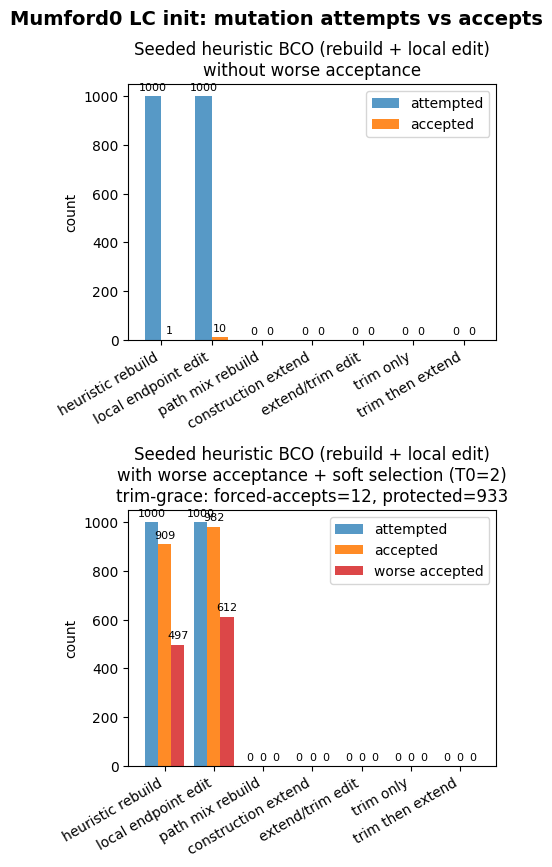

In [11]:
# Unified mutation histogram for the LC-init worse-accept seed sweep.
# Grid: rows = accept experiments, cols = BCO variants; bars are
# attempted / accepted / worse-accepted per mutation type, seed-averaged.
plot_sweep_mutation_grid(worse_accept_seed_sweep, "Mumford0 LC init")


## 8b. NX Heuristic Dataset BCO Seed Sweep

This block repeats the same BCO worse-accept seed sweep on one graph from `examples/nx_heuristic_results_10r_len12`. The main Mumford0/Initial-LC sweep above is left unchanged.


In [12]:
# Dataset graph source for a separate BCO seed sweep on one graph only.
import pickle
import random

from connectpt.routes_generator.citygraph_dataset import STOP_KEY

NX_SWEEP_RAW_GRAPHS_PATH = ROOT_DIR / "examples" / "data" / "raw_graphs_1000.pkl"
NX_SWEEP_RESULTS_DIR = ROOT_DIR / "examples" / "nx_heuristic_results_10r_len12"
NX_SWEEP_GRAPH_INDEX = 0


def load_single_nx_heuristic_graph_and_routes(raw_graphs_path, results_dir, graph_index):
    graph_index = int(graph_index)
    # raw_graphs_1000.pkl is a single pickle, so loading the file reads the
    # list, but this sweep uses only the selected graph and one route file.
    with Path(raw_graphs_path).open("rb") as file:
        graphs = pickle.load(file)
    graph = graphs[graph_index]

    graph_dir = Path(results_dir) / f"graph_{graph_index:04d}"
    route_path = graph_dir / f"lc_lc_graph_{graph_index:04d}_routes_routes.pkl"
    if not route_path.exists():
        matches = sorted(graph_dir.glob("lc_*_routes_routes.pkl"))
        if not matches:
            raise FileNotFoundError(route_path)
        route_path = matches[0]

    with route_path.open("rb") as file:
        routes = pickle.load(file)
    if isinstance(routes, list):
        routes = routes[0]
    routes = torch.as_tensor(routes, dtype=torch.long)
    if routes.ndim == 3 and routes.shape[0] == 1:
        routes = routes.squeeze(0)
    if routes.ndim != 2:
        raise ValueError(f"Expected routes with shape (n_routes, len), got {tuple(routes.shape)}")

    used_columns = (routes >= 0).any(dim=0).nonzero().flatten()
    route_width = int(used_columns[-1].item()) + 1 if used_columns.numel() else 1
    route_width = min(route_width, MAX_ROUTE_LEN)
    routes = routes[:, :route_width]

    route_batch = torch.full(
        (1, N_ROUTES, MAX_ROUTE_LEN),
        -1,
        dtype=torch.long,
    )
    n_copy_routes = min(N_ROUTES, routes.shape[0])
    n_copy_stops = min(MAX_ROUTE_LEN, routes.shape[1])
    route_batch[0, :n_copy_routes, :n_copy_stops] = routes[:n_copy_routes, :n_copy_stops]
    return graph, route_batch, route_path


(
    nx_sweep_graph,
    nx_sweep_initial_routes,
    nx_sweep_route_path,
) = load_single_nx_heuristic_graph_and_routes(
    NX_SWEEP_RAW_GRAPHS_PATH,
    NX_SWEEP_RESULTS_DIR,
    NX_SWEEP_GRAPH_INDEX,
)

nx_sweep_route_lengths = (nx_sweep_initial_routes > -1).sum(dim=-1)
nx_sweep_real_route_lengths = nx_sweep_route_lengths[nx_sweep_route_lengths > 0]
assert nx_sweep_initial_routes.shape == (1, N_ROUTES, MAX_ROUTE_LEN), nx_sweep_initial_routes.shape
assert int(nx_sweep_real_route_lengths.min().item()) == MAX_ROUTE_LEN, nx_sweep_real_route_lengths.tolist()
assert int(nx_sweep_real_route_lengths.max().item()) == MAX_ROUTE_LEN, nx_sweep_real_route_lengths.tolist()


def nx_graph_to_tensor_dataset(graph):
    n_nodes = graph[STOP_KEY].pos.shape[0]
    return {
        "node_locs": graph[STOP_KEY].pos[:n_nodes].detach().cpu(),
        "street_adj": graph.street_adj[:n_nodes, :n_nodes].detach().cpu(),
        "demand": graph.demand[:n_nodes, :n_nodes].detach().cpu(),
    }
nx_sweep_tensors = nx_graph_to_tensor_dataset(nx_sweep_graph)
print(
    f"NX dataset sweep graph={NX_SWEEP_GRAPH_INDEX}, "
    f"nodes={nx_sweep_graph[STOP_KEY].num_nodes}, "
    f"seed_routes_shape={tuple(nx_sweep_initial_routes.shape)}, route_file={nx_sweep_route_path.name}"
)


NX dataset sweep graph=0, nodes=50, seed_routes_shape=(1, 10, 12), route_file=lc_nx_heuristic_graph_0000_routes_routes.pkl


In [13]:
NX_DATASET_SWEEP_SEEDS = WORSE_ACCEPT_SEEDS
NX_DATASET_SWEEP_ACCEPT_EXPERIMENTS = WORSE_ACCEPT_EXPERIMENTS
NX_DATASET_SWEEP_VARIANT_KEYS = [variant["key"] for variant in BCO_VARIANTS]
NX_DATASET_SWEEP_DUMP_ROUTES = False
REUSE_EXISTING_NX_SWEEP_RESULTS = True


def run_nx_dataset_bco_seed_sweep(
    seeds=None,
    accept_experiments=None,
    variant_keys=None,
    mode_key="uniform",
):
    if seeds is None:
        seeds = NX_DATASET_SWEEP_SEEDS
    if accept_experiments is None:
        accept_experiments = NX_DATASET_SWEEP_ACCEPT_EXPERIMENTS
    if variant_keys is None:
        variant_keys = NX_DATASET_SWEEP_VARIANT_KEYS

    selected_variants = [
        variant for variant in BCO_VARIANTS if variant["key"] in set(variant_keys)
    ]
    mode_cfg = BCO_ROUTE_SELECTION_MODES[mode_key]
    rows = []
    results = {}
    total_runs = len(accept_experiments) * len(selected_variants) * len(seeds)
    run_idx = 0

    for accept_cfg in accept_experiments:
        accept_key = accept_cfg["key"]
        results[accept_key] = {}
        for variant in selected_variants:
            variant_results = []
            for seed in seeds:
                run_idx += 1
                random.seed(int(seed))
                np.random.seed(int(seed))
                torch.manual_seed(int(seed))
                print(
                    f"[nx {run_idx}/{total_runs}] graph={NX_SWEEP_GRAPH_INDEX} | "
                    f"{accept_key} | {variant['key']} | seed={seed}"
                )
                cfg = build_bco_cfg(
                    run_name=route_selection_run_name(
                        f"nx_dataset_g{NX_SWEEP_GRAPH_INDEX}_{variant['run_name']}_{accept_key}_seed{seed}",
                        mode_key,
                    ),
                    n_routes=N_ROUTES,
                    min_route_len=MIN_ROUTE_LEN,
                    max_route_len=MAX_ROUTE_LEN,
                    use_neural_bees=variant["use_neural_bees"],
                    n_type1_bees=variant["n_type1_bees"],
                    n_type2_bees=variant["n_type2_bees"],
                    n_type4_bees=variant["n_type4_bees"],
                    n_type5_bees=variant.get("n_type5_bees", 0),
                    n_type6_bees=variant.get("n_type6_bees", 0),
                    n_type7_bees=variant.get("n_type7_bees", 0),
                    ignore_type4_max_route_len=BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
                    ignore_type5_max_route_len=BCO_EDIT_IGNORE_MAX_ROUTE_LEN,
                    ignore_type6_max_route_len=BCO_TRIM_IGNORE_MAX_ROUTE_LEN,
                    ignore_type7_max_route_len=BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN,
                    use_demand_weighted_route_selection=mode_cfg["use_demand_weighted_route_selection"],
                    worse_accept_temperature=accept_cfg["temperature"],
                    worse_accept_decay=accept_cfg["decay"],
                    worse_accept_min_temperature=accept_cfg["min_temperature"],
                    worse_selection_temperature=accept_cfg["selection_temperature"],
                    worse_selection_decay=accept_cfg["selection_decay"],
                    worse_selection_min_temperature=accept_cfg["selection_min_temperature"],
                    worse_selection_uniform_mix=accept_cfg["selection_uniform_mix"],
                    worse_selection_elite_count=accept_cfg["selection_elite_count"],
                    trim_grace_period=accept_cfg.get("trim_grace_period", 0),
                )
                cfg.experiment.seed = int(seed)

                mutation_counts = {}
                run_name, metrics, unserved_demand, routes, mutation_counts = run_bco(
                    cfg,
                    nx_sweep_initial_routes,
                    mutation_counts_out=mutation_counts,
                    tensors=nx_sweep_tensors,
                    run_name_scope="nx_dataset_",
                )
                if NX_DATASET_SWEEP_DUMP_ROUTES:
                    dump_routes(run_name, routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

                attempted = mutation_stat_bucket(mutation_counts, "attempted")
                accepted = mutation_stat_bucket(mutation_counts, "accepted")
                worse_accepted = mutation_stat_bucket(mutation_counts, "worse_accepted")
                selection_stats = selection_stat_bucket(mutation_counts)
                row = summarize_run(
                    f"{variant['summary_label']} [NX dataset, {accept_cfg['label']}, seed={seed}]",
                    metrics,
                    routes,
                )
                row.update({
                    "graph_source": "nx_heuristic_dataset",
                    "graph_index": int(NX_SWEEP_GRAPH_INDEX),
                    "accept_key": accept_key,
                    "accept_mode": accept_cfg["label"],
                    "worse_accept_temperature": accept_cfg["temperature"],
                    "worse_accept_decay": accept_cfg["decay"],
                    "worse_accept_min_temperature": accept_cfg["min_temperature"],
                    "worse_selection_temperature": accept_cfg["selection_temperature"],
                    "worse_selection_decay": accept_cfg["selection_decay"],
                    "worse_selection_min_temperature": accept_cfg["selection_min_temperature"],
                    "worse_selection_uniform_mix": accept_cfg["selection_uniform_mix"],
                    "worse_selection_elite_count": accept_cfg["selection_elite_count"],
                    "seed": int(seed),
                    "route_selection": mode_cfg["label"],
                    "variant_key": variant["key"],
                    "variant": variant["summary_label"],
                    "heuristic_rebuild_bees": variant["n_type1_bees"],
                    "local_endpoint_edit_bees": bco_variant_type2_bees(variant),
                    "construction_extend_bees": variant["n_type4_bees"],
                    "extend_trim_edit_bees": variant.get("n_type5_bees", 0),
                    "trim_only_bees": variant.get("n_type6_bees", 0),
                    "trim_then_extend_bees": variant.get("n_type7_bees", 0),
                    "attempted_total": sum(attempted.values()),
                    "accepted_total": sum(accepted.values()),
                    "worse_accepted_total": sum(worse_accepted.values()),
                    "selection_parent_copies": selection_stats["parent_copies"],
                    "selection_nonbest_parent_copies": selection_stats["nonbest_parent_copies"],
                    "selection_worse_parent_copies": selection_stats["worse_parent_copies"],
                })
                for type_name in MUTATION_TYPE_KEYS:
                    slug = mutation_slug(type_name)
                    row[f"attempted_{slug}"] = attempted[type_name]
                    row[f"accepted_{slug}"] = accepted[type_name]
                    row[f"worse_accepted_{slug}"] = worse_accepted[type_name]
                rows.append(row)
                variant_results.append({
                    "seed": int(seed),
                    "run_name": run_name,
                    "metrics": metrics,
                    "unserved_demand": unserved_demand,
                    "routes": routes,
                    "routes_tensor": routes,
                    "mutation_counts": mutation_counts,
                })
            results[accept_key][variant["key"]] = variant_results

    rows_df = pd.DataFrame(rows)
    return {
        "rows_df": rows_df,
        "results": results,
        "seeds": list(seeds),
        "accept_experiments": accept_experiments,
        "variant_keys": list(variant_keys),
        "mode_key": mode_key,
        "mode_label": mode_cfg["label"],
        "graph_source": "nx_heuristic_dataset",
        "graph_index": int(NX_SWEEP_GRAPH_INDEX),
        "init_routes": nx_sweep_initial_routes,
        "tensors": nx_sweep_tensors,
    }


if REUSE_EXISTING_NX_SWEEP_RESULTS and "nx_dataset_bco_seed_sweep" in globals():
    print("Reusing existing nx_dataset_bco_seed_sweep; set REUSE_EXISTING_NX_SWEEP_RESULTS=False to rerun BCO.")
else:
    nx_dataset_bco_seed_sweep = run_nx_dataset_bco_seed_sweep()
nx_dataset_bco_rows_df = nx_dataset_bco_seed_sweep["rows_df"]
nx_dataset_bco_summary_df, nx_dataset_bco_comparison_df = summarize_worse_accept_seed_sweep(
    nx_dataset_bco_rows_df
)


[nx 1/2] graph=0 | without_worse | seeded_heuristic | seed=0
[nx_dataset_g0_seeded_bco_heuristic_from_lc_mumford0_without_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


[nx 2/2] graph=0 | with_worse | seeded_heuristic | seed=0
[nx_dataset_g0_seeded_bco_heuristic_from_lc_mumford0_with_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)


,variant_key,variant,accept_key,accept_mode,mean_cost,std_cost,mean_cost_demand_term,std_cost_demand_term,mean_cost_route_term,std_cost_route_term,mean_cost_connectivity_term,std_cost_connectivity_term,mean_cost_penalty_term,std_cost_penalty_term,mean_ATT,std_ATT,mean_RTT,std_RTT,mean_median_connectivity,std_median_connectivity,mean_$d_{un}$,std_$d_{un}$,mean_# disconnected node pairs,std_# disconnected node pairs,mean_# stops out of bounds,std_# stops out of bounds,mean_# routes,std_# routes,n_seeds
0,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),without_worse,without worse acceptance,0.4734,NaN,0.1649,NaN,0.2476,NaN,0.0608,NaN,0.0000,NaN,43.9238,NaN,659.5107,NaN,35.6552,NaN,26.2253,NaN,0.0,NaN,0.0,NaN,10.0,NaN,1
1,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),with_worse,with worse acceptance + soft selection (T0=2),1.7688,NaN,0.2061,NaN,0.4179,NaN,0.0571,NaN,1.0878,NaN,39.1238,NaN,1112.7869,NaN,34.2375,NaN,16.4047,NaN,144.0,NaN,0.0,NaN,10.0,NaN,1


,variant_key,variant,mean_cost_without_worse,mean_cost_with_worse,mean_cost_demand_term_without_worse,mean_cost_demand_term_with_worse,mean_cost_route_term_without_worse,mean_cost_route_term_with_worse,mean_cost_connectivity_term_without_worse,mean_cost_connectivity_term_with_worse,mean_cost_penalty_term_without_worse,mean_cost_penalty_term_with_worse,mean_ATT_without_worse,mean_ATT_with_worse,mean_RTT_without_worse,mean_RTT_with_worse,mean_median_connectivity_without_worse,mean_median_connectivity_with_worse,mean_$d_{un}$_without_worse,mean_$d_{un}$_with_worse,mean_# disconnected node pairs_without_worse,mean_# disconnected node pairs_with_worse,mean_# stops out of bounds_without_worse,mean_# stops out of bounds_with_worse,mean_# routes_without_worse,mean_# routes_with_worse,delta_cost_with_minus_without,delta_ATT_with_minus_without,delta_RTT_with_minus_without
0,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),0.4734,1.7688,0.1649,0.2061,0.2476,0.4179,0.0608,0.0571,0.0,1.0878,43.9238,39.1238,659.5107,1112.7869,35.6552,34.2375,26.2253,16.4047,0.0,144.0,0.0,0.0,10.0,10.0,1.2954,-4.8,453.2762


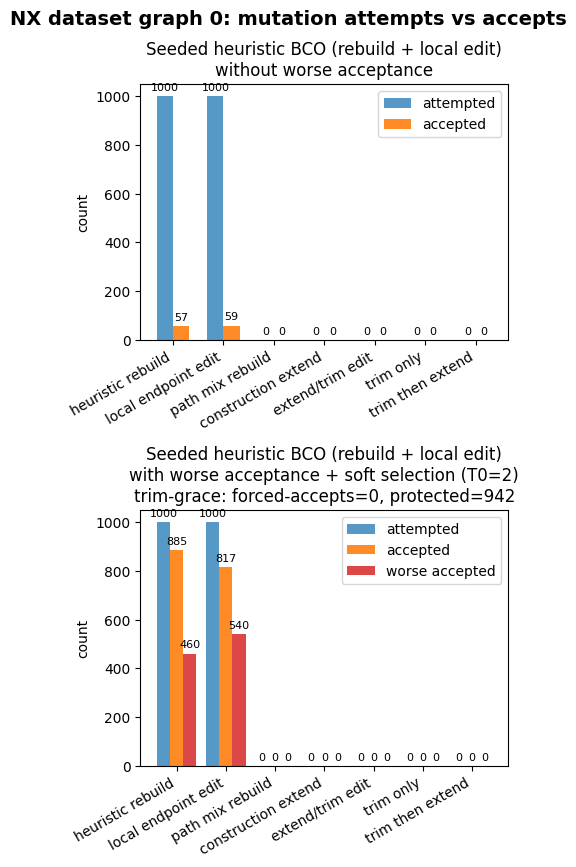

In [14]:
display(nx_dataset_bco_summary_df.round(4))
display(nx_dataset_bco_comparison_df.round(4))

# Same unified mutation histogram as the LC-init sweep, here for the
# NX-heuristic dataset init — so both inits get the identical view.
plot_sweep_mutation_grid(
    nx_dataset_bco_seed_sweep,
    f"NX dataset graph {NX_SWEEP_GRAPH_INDEX}",
)


## 9. Single-Seed Mutation Type Statistics


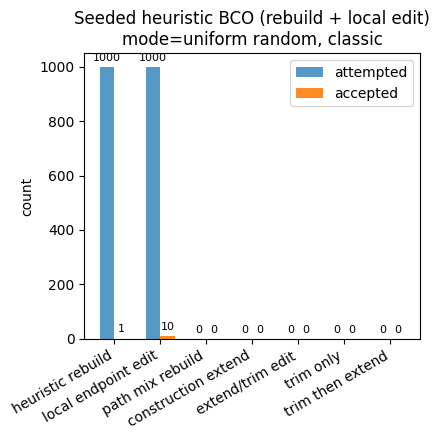

In [15]:
mode_keys = list(BCO_ROUTE_SELECTION_MODES.keys())
fig, axes = plt.subplots(len(mode_keys), len(BCO_VARIANTS), figsize=(4.4 * len(BCO_VARIANTS), 4.5 * len(mode_keys)), squeeze=False)
for row_idx, mode_key in enumerate(mode_keys):
    mode_label = route_selection_mode_label(mode_key)
    for col_idx, variant in enumerate(BCO_VARIANTS):
        result = bco_experiment_results[mode_key][variant["key"]]
        ignore_bits = []
        if variant.get("n_type4_bees", 0):
            ignore_bits.append(f"construction_ignore_max={BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN}")
        if variant.get("n_type5_bees", 0):
            ignore_bits.append(f"edit_ignore_max={BCO_EDIT_IGNORE_MAX_ROUTE_LEN}")
        if variant.get("n_type6_bees", 0):
            ignore_bits.append(f"trim_ignore_max={BCO_TRIM_IGNORE_MAX_ROUTE_LEN}")
        if variant.get("n_type7_bees", 0):
            ignore_bits.append(f"trim_extend_ignore_max={BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN}")
        ignore_text = ", ".join(ignore_bits) if ignore_bits else "classic"
        title = (
            f"{variant['summary_label']}\n"
            f"mode={mode_label}, {ignore_text}"
        )
        plot_mutation_histogram(result["mutation_counts"], title, ax=axes[row_idx, col_idx])
plt.tight_layout()
plt.show()


In [16]:
from IPython.display import display

comparison_rows = [
    {
        **summarize_run("Initial LC", lc_base_metrics, lc_base_routes),
        "route_selection": "n/a",
        "variant": "Initial LC",
    },
    {
        **summarize_run("RL improvement only", rl_improvement_metrics, rl_improvement_routes),
        "route_selection": "n/a",
        "variant": "RL improvement only",
    },
]

for mode_key, mode_cfg in BCO_ROUTE_SELECTION_MODES.items():
    for variant in BCO_VARIANTS:
        result = bco_experiment_results[mode_key][variant["key"]]
        row = summarize_run(
            f"{variant['summary_label']} [{mode_cfg['label']}]",
            result["metrics"],
            result["routes_tensor"],
        )
        row["route_selection"] = mode_cfg["label"]
        row["variant"] = variant["summary_label"]
        comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
initial_lc_row = comparison_df.loc[comparison_df["method"] == "Initial LC"].iloc[0]
comparison_df["delta_cost_vs_initial_lc"] = comparison_df["cost"] - initial_lc_row["cost"]
comparison_df["delta_ATT_vs_initial_lc"] = comparison_df["ATT"] - initial_lc_row["ATT"]
comparison_df["delta_RTT_vs_initial_lc"] = comparison_df["RTT"] - initial_lc_row["RTT"]
comparison_df = comparison_df[[
    "method",
    "route_selection",
    "variant",
    "cost",
    "cost_demand_term",
    "cost_route_term",
    "cost_connectivity_term",
    "cost_penalty_term",
    "ATT",
    "RTT",
    "median_connectivity",
    "$d_{un}$",
    "# disconnected node pairs",
    "# stops out of bounds",
    "# routes",
    "delta_cost_vs_initial_lc",
    "delta_ATT_vs_initial_lc",
    "delta_RTT_vs_initial_lc",
]]

display(comparison_df.round(4))


,method,route_selection,variant,cost,cost_demand_term,cost_route_term,cost_connectivity_term,cost_penalty_term,ATT,RTT,median_connectivity,$d_{un}$,# disconnected node pairs,# stops out of bounds,# routes,delta_cost_vs_initial_lc,delta_ATT_vs_initial_lc,delta_RTT_vs_initial_lc
0,Initial LC,n/a,Initial LC,0.7575,0.2804,0.3833,0.0939,0.0,22.0886,302.0,16.2000,3.7176,0.0,0.0,10,0.000,0.0000,0.0
1,RL improvement only,n/a,RL improvement only,0.7575,0.2804,0.3833,0.0939,0.0,22.0886,302.0,16.2000,3.7176,0.0,0.0,10,0.000,0.0000,0.0
2,Seeded heuristic BCO (rebuild + local edit) [uniform random],uniform random,Seeded heuristic BCO (rebuild + local edit),0.7136,0.2893,0.3275,0.0968,0.0,22.7968,258.0,17.0667,7.4965,0.0,0.0,10,-0.044,0.7082,-44.0


## 10. Route Change Visualization

The initial LC solution is used as the reference. Figures are generated separately for `without_worse` and `with_worse`; each title includes both absolute metrics and the weighted cost terms used in the summed objective.


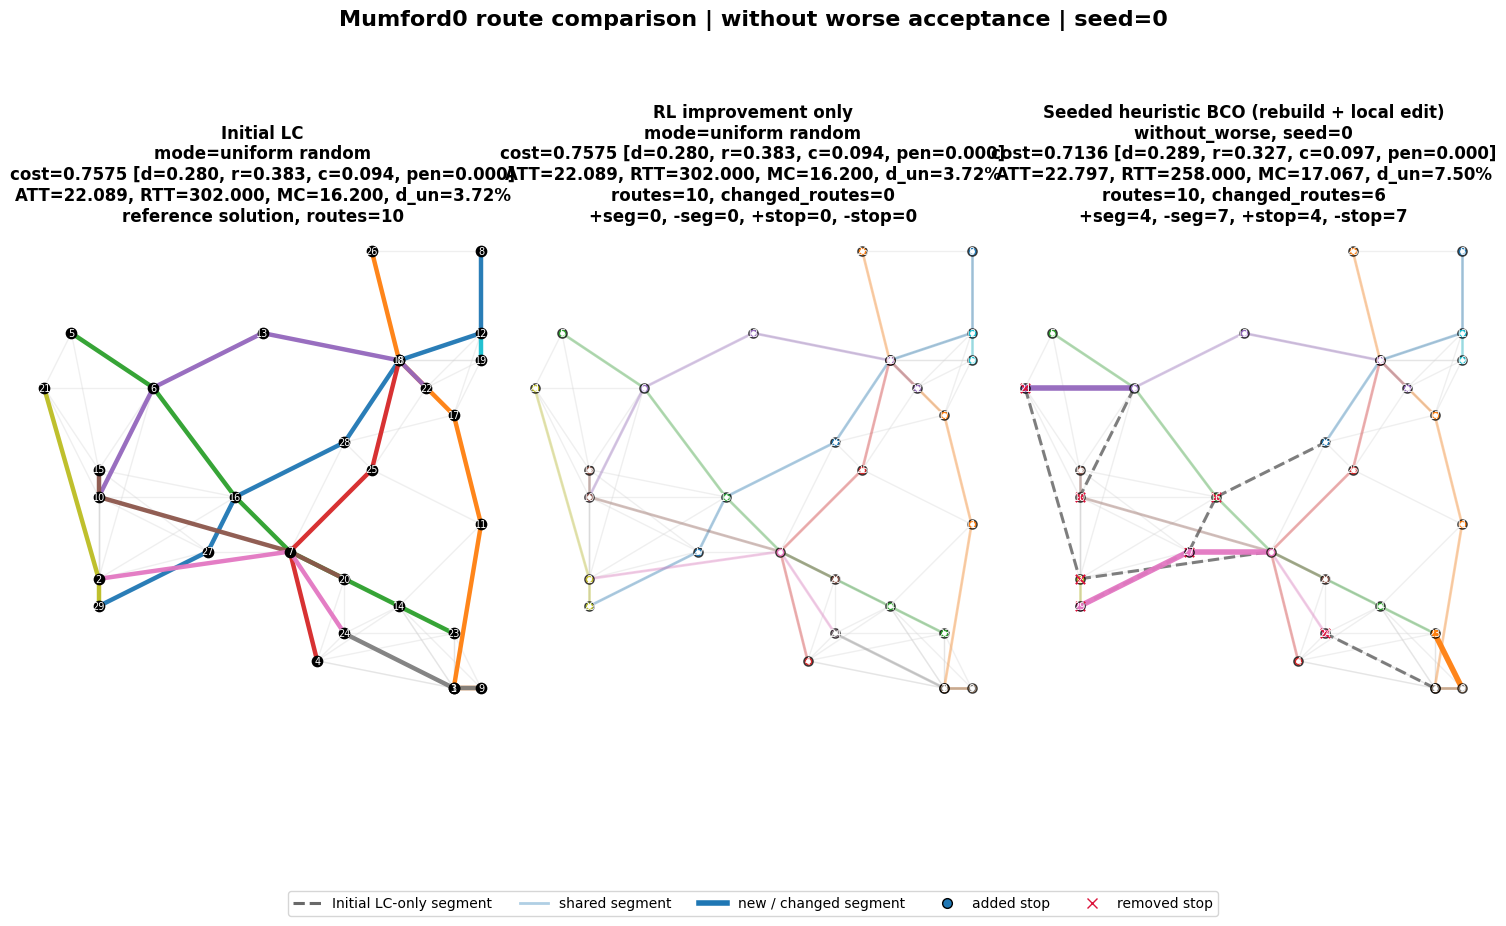

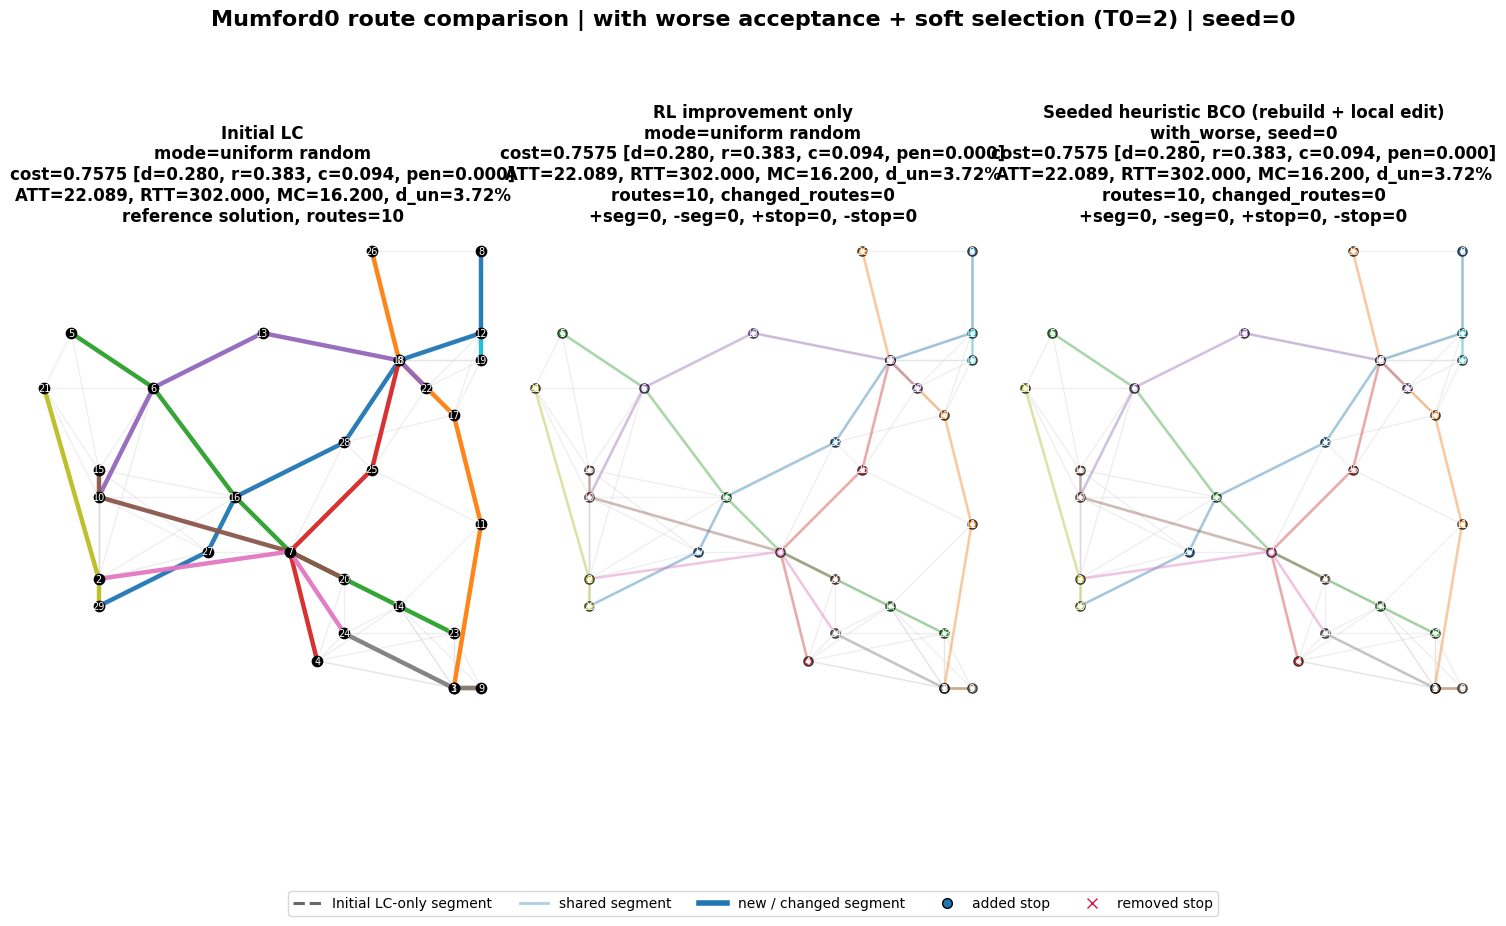

In [17]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from matplotlib.lines import Line2D

# Pull in the shared LC-improvement viz helpers (single source of truth).
# tab10 + straight edges preserve the published evaluation_seeded visual style;
# the lc_improvement_training notebook uses tab20 + curved overlap edges.
_LC_PLOTS_DIR = os.path.abspath(os.path.dirname("__file__")) \
    if "__file__" in dir() else os.path.abspath(".")
if _LC_PLOTS_DIR not in sys.path:
    sys.path.insert(0, _LC_PLOTS_DIR)
import lc_improvement_plots as _plots


def plot_plain_route_set(ax, routes, coords, street_adj, title, subtitle=None):
    return _plots.plot_plain_route_set(
        ax, routes, coords, street_adj,
        title=title, subtitle=subtitle,
        palette="tab10", with_overlap_curves=False,
    )


def plot_route_diff(ax, routes, reference_routes, coords, street_adj,
                    title, subtitle=None):
    return _plots.plot_route_diff(
        ax, routes, reference_routes, coords, street_adj,
        title=title, subtitle=subtitle,
        palette="tab10", with_overlap_curves=False,
    )


# Re-export the data-only helpers under their original names so the driver
# code below works unchanged.
get_first_route_set = _plots.get_first_route_set
route_to_list = _plots.route_to_list
route_edge_list = _plots.route_edge_list
undirected_edge_key = _plots.undirected_edge_key
draw_street_graph = _plots.draw_street_graph
plot_edges = _plots.plot_edges
summarize_route_changes = _plots.summarize_route_changes


def get_worse_plot_result(sweep_results: dict, accept_key: str, variant_key: str, seed: int):
    variant_results = sweep_results["results"][accept_key][variant_key]
    for result in variant_results:
        if int(result["seed"]) == int(seed):
            return result
    return variant_results[0]


coords = input_tensors["node_locs"]
street_adj = input_tensors["street_adj"]
mode_keys = ["uniform"]
worse_plot_sweep = worse_accept_seed_sweep
WORSE_ROUTE_PLOT_SEED = int(worse_plot_sweep["seeds"][0])

style_handles = [
    Line2D([0], [0], color="dimgray", lw=2.2, linestyle="--", label="Initial LC-only segment"),
    Line2D([0], [0], color="tab:blue", lw=2.0, alpha=0.35, label="shared segment"),
    Line2D([0], [0], color="tab:blue", lw=4.0, label="new / changed segment"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="tab:blue", markersize=7, lw=0, label="added stop"),
    Line2D([0], [0], marker="x", color="crimson", markersize=7, lw=0, label="removed stop"),
]

for accept_cfg in WORSE_ACCEPT_EXPERIMENTS:
    accept_key = accept_cfg["key"]
    n_comparison_cols = 2 + len(BCO_VARIANTS)
    fig, axes = plt.subplots(
        len(mode_keys),
        n_comparison_cols,
        figsize=(4.9 * n_comparison_cols, 9 * len(mode_keys)),
        squeeze=False,
        constrained_layout=True,
    )
    for row_idx, mode_key in enumerate(mode_keys):
        mode_label = route_selection_mode_label(mode_key)
        comparison_rows = [
            {
                "label": f"Initial LC\nmode={mode_label}",
                "routes": lc_base_routes,
                "metrics": lc_base_metrics,
                "is_reference": True,
            },
            {
                "label": f"RL improvement only\nmode={mode_label}",
                "routes": rl_improvement_routes,
                "metrics": rl_improvement_metrics,
                "is_reference": False,
            },
        ]
        for variant in BCO_VARIANTS:
            result = get_worse_plot_result(
                worse_plot_sweep,
                accept_key,
                variant["key"],
                WORSE_ROUTE_PLOT_SEED,
            )
            comparison_rows.append({
                "label": f"{variant['summary_label']}\n{accept_key}, seed={WORSE_ROUTE_PLOT_SEED}",
                "routes": result["routes_tensor"],
                "metrics": result["metrics"],
                "is_reference": False,
            })
        reference_row = comparison_rows[0]

        for ax, row in zip(axes[row_idx], comparison_rows):
            if row["is_reference"]:
                ref_routes = get_first_route_set(row["routes"])
                n_nonempty_routes = int(((ref_routes > -1).sum(dim=-1) > 1).sum().item())
                subtitle = (
                    f"{format_plot_metrics(row['metrics'])}"
                    f"\nreference solution, routes={n_nonempty_routes}"
                )
                plot_plain_route_set(ax, row["routes"], coords, street_adj, row["label"], subtitle)
                continue

            change_summary = summarize_route_changes(row["routes"], reference_row["routes"])
            compared_routes = get_first_route_set(row["routes"])
            n_nonempty_routes = int(((compared_routes > -1).sum(dim=-1) > 1).sum().item())
            subtitle = (
                f"{format_plot_metrics(row['metrics'])}"
                f"\nroutes={n_nonempty_routes}, changed_routes={change_summary['changed_routes']}"
                f"\n+seg={change_summary['added_edges']}, -seg={change_summary['removed_edges']}, "
                f"+stop={change_summary['added_stops']}, -stop={change_summary['removed_stops']}"
            )
            plot_route_diff(ax, row["routes"], reference_row["routes"], coords, street_adj, row["label"], subtitle)

    fig.suptitle(
        f"Mumford0 route comparison | {accept_cfg['label']} | seed={WORSE_ROUTE_PLOT_SEED}",
        fontsize=16,
        fontweight="bold",
    )
    fig.legend(handles=style_handles, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=True)
    plt.show()

PLOT_FOCUSED_ROUTE_DIFFS = False

if PLOT_FOCUSED_ROUTE_DIFFS:
    focus_variant_keys = [
        "heuristic_extend_trim_split_5_5",
        "extend_trim_edit_only",
        "trim_then_extend_only",
        "construction_only",
        "construction_trim_split_5_5",
        "construction_trim_split_8_2",
    ]
    focus_variant_keys = [
        key for key in focus_variant_keys
        if any(variant["key"] == key for variant in BCO_VARIANTS)
    ]
    for accept_cfg in WORSE_ACCEPT_EXPERIMENTS:
        accept_key = accept_cfg["key"]
        focus_cols = 1 + len(focus_variant_keys)
        fig, axes = plt.subplots(
            len(mode_keys),
            focus_cols,
            figsize=(7 * focus_cols, 7 * len(mode_keys)),
            squeeze=False,
            constrained_layout=True,
        )
        for row_idx, mode_key in enumerate(mode_keys):
            mode_label = route_selection_mode_label(mode_key)
            reference_routes = get_first_route_set(lc_base_routes)
            reference_nonempty = int(((reference_routes > -1).sum(dim=-1) > 1).sum().item())
            plot_plain_route_set(
                axes[row_idx, 0],
                lc_base_routes,
                coords,
                street_adj,
                f"Initial LC reference\nmode={mode_label}",
                subtitle=(
                    f"{format_plot_metrics(lc_base_metrics)}\n"
                    f"routes={reference_nonempty}"
                ),
            )

            for col_idx, variant_key in enumerate(focus_variant_keys, start=1):
                result = get_worse_plot_result(
                    worse_plot_sweep,
                    accept_key,
                    variant_key,
                    WORSE_ROUTE_PLOT_SEED,
                )
                change_summary = summarize_route_changes(result["routes_tensor"], lc_base_routes)
                result_routes = get_first_route_set(result["routes_tensor"])
                result_nonempty = int(((result_routes > -1).sum(dim=-1) > 1).sum().item())
                plot_route_diff(
                    axes[row_idx, col_idx],
                    result["routes_tensor"],
                    lc_base_routes,
                    coords,
                    street_adj,
                    f"{variant_key}\n{accept_key}, seed={WORSE_ROUTE_PLOT_SEED}",
                    subtitle=(
                        f"{format_plot_metrics(result['metrics'])}\n"
                        f"routes={result_nonempty}, "
                        f"changed_routes={change_summary['changed_routes']}\n"
                        f"+seg={change_summary['added_edges']}, "
                        f"-seg={change_summary['removed_edges']}, "
                        f"+stop={change_summary['added_stops']}, "
                        f"-stop={change_summary['removed_stops']}"
                    ),
                )

        fig.suptitle(
            f"Focused Mumford0 route diffs | {accept_cfg['label']} | seed={WORSE_ROUTE_PLOT_SEED}",
            fontsize=16,
            fontweight="bold",
        )
        fig.legend(handles=style_handles, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=True)
        plt.show()


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


[nx_heuristic_dataset_graph_seeded_bco_heuristic_from_lc_mumford0_without_worse_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[nx_heuristic_dataset_graph_seeded_bco_heuristic_from_lc_mumford0_with_worse_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)


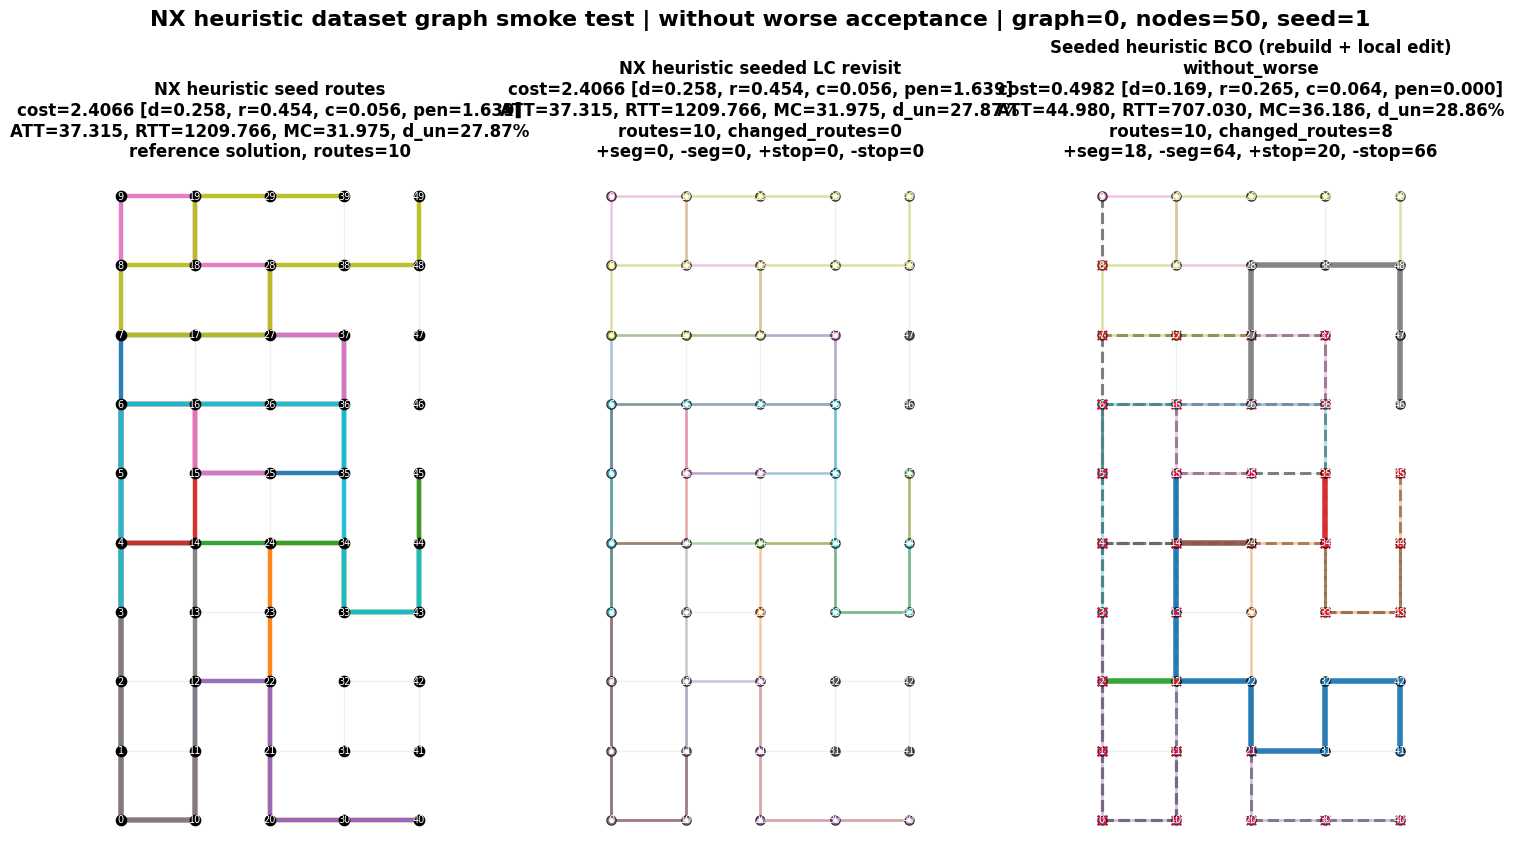

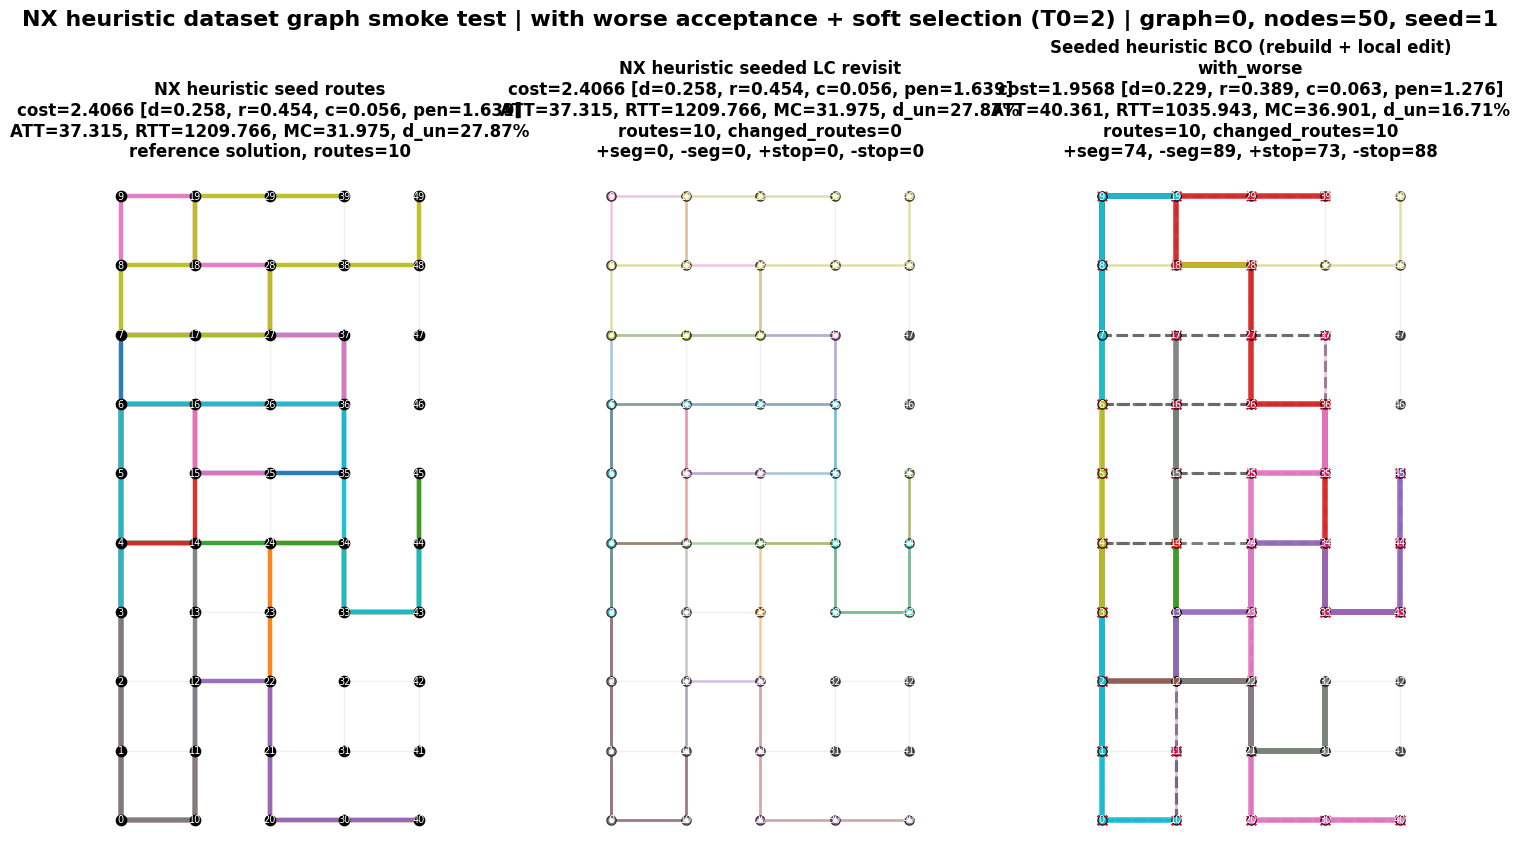

In [18]:
# NX heuristic dataset smoke test: run the same seeded-LC/BCO visualization on one generated dataset graph.
import random

from connectpt.routes_generator.citygraph_dataset import STOP_KEY

RAW_GRAPHS_PATH = ROOT_DIR / "examples" / "data" / "raw_graphs_1000.pkl"
NX_HEURISTIC_RESULTS_DIR = ROOT_DIR / "examples" / "nx_heuristic_results_10r_len12"
NX_HEURISTIC_TEST_GRAPH_INDEX = 0
if "nx_dataset_bco_seed_sweep" not in globals():
    raise RuntimeError("Run the NX dataset BCO seed sweep cell before this display/plot cell.")
DATASET_TEST_SEED = int(nx_dataset_bco_seed_sweep["seeds"][0])
DATASET_TEST_VARIANT_KEYS = [variant["key"] for variant in BCO_VARIANTS]

random.seed(DATASET_TEST_SEED)
np.random.seed(DATASET_TEST_SEED)
torch.manual_seed(DATASET_TEST_SEED)

nx_graphs, nx_seed_routes = load_raw_graphs_and_lc_routes(
    RAW_GRAPHS_PATH,
    NX_HEURISTIC_RESULTS_DIR,
)
dataset_test_graph = nx_graphs[NX_HEURISTIC_TEST_GRAPH_INDEX]
dataset_test_initial_routes = nx_seed_routes[
    NX_HEURISTIC_TEST_GRAPH_INDEX:NX_HEURISTIC_TEST_GRAPH_INDEX + 1
].clone()

route_lengths = (dataset_test_initial_routes > -1).sum(dim=-1)
real_route_lengths = route_lengths[route_lengths > 0]
assert dataset_test_initial_routes.shape[1] == N_ROUTES, dataset_test_initial_routes.shape
assert int(real_route_lengths.min().item()) == MAX_ROUTE_LEN, real_route_lengths.tolist()
assert int(real_route_lengths.max().item()) == MAX_ROUTE_LEN, real_route_lengths.tolist()
def evaluate_routes_on_tensors(cfg, tensors, routes_tensor):
    dataloader = make_tensor_dataloader(cfg.eval.dataset, tensors)
    device, run_name, _, cost_obj, _ = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix="dataset_seed_eval_",
        weights_required=True,
    )
    output = lrnu.test_method(
        None,
        dataloader,
        cfg.eval,
        OmegaConf.create({"method": "tensor"}),
        cost_obj,
        silent=True,
        device=device,
        return_routes=True,
        routes_tensor=routes_tensor,
    )
    _, _, unserved_demand, metrics, routes = output
    routes_tensor = as_route_tensor(routes)
    metrics = add_cost_breakdown_to_metrics(metrics, dataloader, cfg.eval, cost_obj, routes_tensor, device)
    return run_name, metrics, unserved_demand, routes_tensor
dataset_test_tensors = nx_graph_to_tensor_dataset(dataset_test_graph)
dataset_test_eval_cfg = build_lc_cfg(
    run_name="nx_heuristic_seed_eval",
    n_routes=N_ROUTES,
    min_route_len=MIN_ROUTE_LEN,
    max_route_len=MAX_ROUTE_LEN,
)
(
    dataset_test_initial_run_name,
    dataset_test_initial_metrics,
    dataset_test_initial_unserved,
    dataset_test_initial_routes_eval,
) = evaluate_routes_on_tensors(
    dataset_test_eval_cfg,
    dataset_test_tensors,
    dataset_test_initial_routes,
)

dataset_test_lc_seeded_cfg = build_lc_cfg(
    run_name="nx_heuristic_dataset_graph_seeded_lc_second_pass",
    n_routes=N_ROUTES,
    min_route_len=MIN_ROUTE_LEN,
    max_route_len=MAX_ROUTE_LEN,
)
(
    dataset_test_lc_seeded_run_name,
    dataset_test_lc_seeded_metrics,
    dataset_test_lc_seeded_unserved,
    dataset_test_lc_seeded_routes,
    dataset_test_lc_seeded_step_counts,
) = run_lc(
    dataset_test_lc_seeded_cfg,
    revisit_routes=dataset_test_initial_routes,
    tensors=dataset_test_tensors,
    run_name_prefix="dataset_lc_",
)

DATASET_TEST_ACCEPT_EXPERIMENTS = nx_dataset_bco_seed_sweep["accept_experiments"]
DATASET_TEST_VARIANT_KEYS = nx_dataset_bco_seed_sweep["variant_keys"]
assert int(nx_dataset_bco_seed_sweep["graph_index"]) == int(NX_HEURISTIC_TEST_GRAPH_INDEX)

dataset_test_bco_results = {}
for accept_cfg in DATASET_TEST_ACCEPT_EXPERIMENTS:
    accept_key = accept_cfg["key"]
    dataset_test_bco_results[accept_key] = {}
    for variant in BCO_VARIANTS:
        if variant["key"] not in DATASET_TEST_VARIANT_KEYS:
            continue
        variant_runs = nx_dataset_bco_seed_sweep["results"][accept_key][variant["key"]]
        result = next(
            (run for run in variant_runs if int(run["seed"]) == int(DATASET_TEST_SEED)),
            variant_runs[0],
        )
        dataset_test_bco_results[accept_key][variant["key"]] = {
            "variant_label": variant["summary_label"],
            "run_name": result["run_name"],
            "metrics": result["metrics"],
            "unserved_demand": result["unserved_demand"],
            "routes_tensor": as_route_tensor(result["routes_tensor"]),
            "mutation_counts": result["mutation_counts"],
            "n_type4_bees": variant["n_type4_bees"],
            "n_type5_bees": variant.get("n_type5_bees", 0),
            "n_type6_bees": variant.get("n_type6_bees", 0),
            "n_type7_bees": variant.get("n_type7_bees", 0),
            "source_seed": int(result["seed"]),
        }

coords = dataset_test_tensors["node_locs"]
street_adj = dataset_test_tensors["street_adj"]
n_nodes = int(dataset_test_graph[STOP_KEY].num_nodes)

for accept_cfg in DATASET_TEST_ACCEPT_EXPERIMENTS:
    accept_key = accept_cfg["key"]
    comparison_rows = [
        {
            "label": "NX heuristic seed routes",
            "routes": dataset_test_initial_routes_eval,
            "metrics": dataset_test_initial_metrics,
            "is_reference": True,
        },
        {
            "label": "NX heuristic seeded LC revisit",
            "routes": dataset_test_lc_seeded_routes,
            "metrics": dataset_test_lc_seeded_metrics,
            "is_reference": False,
        },
    ]
    for variant in BCO_VARIANTS:
        result = dataset_test_bco_results[accept_key].get(variant["key"])
        if result is None:
            continue
        comparison_rows.append({
            "label": f"{result['variant_label']}\n{accept_key}",
            "routes": result["routes_tensor"],
            "metrics": result["metrics"],
            "is_reference": False,
        })

    n_cols = len(comparison_rows)
    fig, axes = plt.subplots(1, n_cols, figsize=(4.9 * n_cols, 8.5), squeeze=False, constrained_layout=True)
    reference_row = comparison_rows[0]
    for ax, row in zip(axes[0], comparison_rows):
        if row["is_reference"]:
            ref_routes = get_first_route_set(row["routes"])
            n_nonempty_routes = int(((ref_routes > -1).sum(dim=-1) > 1).sum().item())
            subtitle = (
                f"{format_plot_metrics(row['metrics'])}"
                f"\nreference solution, routes={n_nonempty_routes}"
            )
            plot_plain_route_set(ax, row["routes"], coords, street_adj, row["label"], subtitle)
            continue

        change_summary = summarize_route_changes(row["routes"], reference_row["routes"])
        compared_routes = get_first_route_set(row["routes"])
        n_nonempty_routes = int(((compared_routes > -1).sum(dim=-1) > 1).sum().item())
        subtitle = (
            f"{format_plot_metrics(row['metrics'])}"
            f"\nroutes={n_nonempty_routes}, changed_routes={change_summary['changed_routes']}"
            f"\n+seg={change_summary['added_edges']}, -seg={change_summary['removed_edges']}, "
            f"+stop={change_summary['added_stops']}, -stop={change_summary['removed_stops']}"
        )
        plot_route_diff(ax, row["routes"], reference_row["routes"], coords, street_adj, row["label"], subtitle)

    fig.suptitle(
        f"NX heuristic dataset graph smoke test | {accept_cfg['label']} | graph={NX_HEURISTIC_TEST_GRAPH_INDEX}, nodes={n_nodes}, seed={DATASET_TEST_SEED}",
        fontsize=16,
        fontweight="bold",
    )
    plt.show()

# NX heuristic comparison table in the same shape as the LC/BCO summary.
from IPython.display import display

(
    dataset_test_rl_improvement_run_name,
    dataset_test_rl_improvement_metrics,
    dataset_test_rl_improvement_unserved,
    dataset_test_rl_improvement_routes,
    _,
) = run_rl_improvement(
    dataset_test_initial_routes,
    run_name=f"nx_heuristic_dataset_graph_rl_improvement_seed{DATASET_TEST_SEED}",
    tensors=dataset_test_tensors,
)

nx_heuristic_comparison_rows = [
    {
        **summarize_run("Initial NX-heuristic", dataset_test_initial_metrics, dataset_test_initial_routes_eval),
        "route_selection": "n/a",
        "accept_mode": "n/a",
        "variant": "Initial NX-heuristic",
    },
    {
        **summarize_run("NX heuristic seeded LC revisit", dataset_test_lc_seeded_metrics, dataset_test_lc_seeded_routes),
        "route_selection": "n/a",
        "accept_mode": "n/a",
        "variant": "NX heuristic seeded LC revisit",
    },
    {
        **summarize_run("RL improvement only", dataset_test_rl_improvement_metrics, dataset_test_rl_improvement_routes),
        "route_selection": "n/a",
        "accept_mode": "n/a",
        "variant": "RL improvement only",
    },
]

for accept_cfg in DATASET_TEST_ACCEPT_EXPERIMENTS:
    accept_key = accept_cfg["key"]
    for variant in BCO_VARIANTS:
        result = dataset_test_bco_results[accept_key].get(variant["key"])
        if result is None:
            continue
        row = summarize_run(
            f"{variant['summary_label']} [{accept_cfg['label']}]",
            result["metrics"],
            result["routes_tensor"],
        )
        row["route_selection"] = BCO_ROUTE_SELECTION_MODES["uniform"]["label"]
        row["accept_mode"] = accept_cfg["label"]
        row["variant"] = variant["summary_label"]
        nx_heuristic_comparison_rows.append(row)

nx_heuristic_comparison_df = pd.DataFrame(nx_heuristic_comparison_rows)
initial_nx_row = nx_heuristic_comparison_df.loc[
    nx_heuristic_comparison_df["method"] == "Initial NX-heuristic"
].iloc[0]
nx_heuristic_comparison_df["delta_cost_vs_initial_nx"] = nx_heuristic_comparison_df["cost"] - initial_nx_row["cost"]
nx_heuristic_comparison_df["delta_ATT_vs_initial_nx"] = nx_heuristic_comparison_df["ATT"] - initial_nx_row["ATT"]
nx_heuristic_comparison_df["delta_RTT_vs_initial_nx"] = nx_heuristic_comparison_df["RTT"] - initial_nx_row["RTT"]
nx_heuristic_comparison_df = nx_heuristic_comparison_df[[
    "method",
    "route_selection",
    "accept_mode",
    "variant",
    "cost",
    "cost_demand_term",
    "cost_route_term",
    "cost_connectivity_term",
    "cost_penalty_term",
    "ATT",
    "RTT",
    "median_connectivity",
    "$d_{un}$",
    "# disconnected node pairs",
    "# stops out of bounds",
    "# routes",
    "delta_cost_vs_initial_nx",
    "delta_ATT_vs_initial_nx",
    "delta_RTT_vs_initial_nx",
]]

display(nx_heuristic_comparison_df.round(4))


In [19]:
# Objective-weight comparison on one NX-heuristic dataset graph.
# For each (demand, route, connectivity) cost-weight combination we score
# the initial NX-heuristic routes, run the seeded-heuristic BCO variant,
# and run RL-improvement-only -- all on the same graph (reused from the
# cell-30 smoke test: dataset_test_graph / dataset_test_tensors /
# dataset_test_initial_routes).
from IPython.display import display

NX_WEIGHT_COMBOS = [
    ("balanced(0.33/0.33/0.33)", 0.33, 0.33, 0.33),
    ("demand-only(1/0/0)", 1.0, 0.0, 0.0),
    ("route-only(0/1/0)", 0.0, 1.0, 0.0),
    ("connectivity-only(0/0/1)", 0.0, 0.0, 1.0),
]
nx_weight_variant = next(
    variant for variant in BCO_VARIANTS if variant["key"] == "seeded_heuristic"
)

nx_weight_rows = []
for combo_label, w_demand, w_route, w_conn in NX_WEIGHT_COMBOS:
    print(f"--- objective weights: {combo_label} ---")
    weights = {
        "demand_time_weight": w_demand,
        "route_time_weight": w_route,
        "median_connectivity_weight": w_conn,
    }

    # Initial NX-heuristic routes scored under these cost weights.
    initial_eval_cfg = build_lc_cfg(
        run_name=f"nx_weight_initial_{combo_label}",
        n_routes=N_ROUTES,
        min_route_len=MIN_ROUTE_LEN,
        max_route_len=MAX_ROUTE_LEN,
        **weights,
    )
    _, nx_weight_initial_metrics, _, _ = evaluate_routes_on_tensors(
        initial_eval_cfg, dataset_test_tensors, dataset_test_initial_routes
    )
    nx_weight_rows.append({
        **summarize_run("Initial NX-heuristic",
                        nx_weight_initial_metrics, dataset_test_initial_routes),
        "weights": combo_label,
    })

    # Seeded-heuristic BCO (rebuild + local edit) under these weights.
    nx_weight_bco_cfg = build_bco_cfg(
        run_name=route_selection_run_name(
            f"nx_weight_{nx_weight_variant['run_name']}_{combo_label}",
            "uniform",
        ),
        n_routes=N_ROUTES,
        min_route_len=MIN_ROUTE_LEN,
        max_route_len=MAX_ROUTE_LEN,
        use_neural_bees=nx_weight_variant["use_neural_bees"],
        n_type1_bees=nx_weight_variant["n_type1_bees"],
        n_type2_bees=nx_weight_variant["n_type2_bees"],
        n_type4_bees=nx_weight_variant["n_type4_bees"],
        n_type5_bees=nx_weight_variant.get("n_type5_bees", 0),
        n_type6_bees=nx_weight_variant.get("n_type6_bees", 0),
        n_type7_bees=nx_weight_variant.get("n_type7_bees", 0),
        **weights,
    )
    nx_weight_bco_cfg.experiment.seed = DATASET_TEST_SEED
    nx_weight_bco_mc = {}
    (
        _,
        nx_weight_bco_metrics,
        _,
        nx_weight_bco_routes,
        nx_weight_bco_mc,
    ) = run_bco(
        nx_weight_bco_cfg,
        dataset_test_initial_routes,
        mutation_counts_out=nx_weight_bco_mc,
        tensors=dataset_test_tensors,
        run_name_scope="nx_weight_",
    )
    nx_weight_rows.append({
        **summarize_run(nx_weight_variant["summary_label"],
                        nx_weight_bco_metrics, nx_weight_bco_routes),
        "weights": combo_label,
    })

    # RL improvement only under these weights.
    (
        _,
        nx_weight_rl_metrics,
        _,
        nx_weight_rl_routes,
        _,
    ) = run_rl_improvement(
        dataset_test_initial_routes,
        run_name=f"nx_weight_rl_{combo_label}",
        tensors=dataset_test_tensors,
        weights=weights,
    )
    nx_weight_rows.append({
        **summarize_run("RL improvement only",
                        nx_weight_rl_metrics, nx_weight_rl_routes),
        "weights": combo_label,
    })

nx_weight_df = pd.DataFrame(nx_weight_rows)
nx_weight_df = nx_weight_df[[
    "weights",
    "method",
    "cost",
    "cost_demand_term",
    "cost_route_term",
    "cost_connectivity_term",
    "cost_penalty_term",
    "ATT",
    "RTT",
    "median_connectivity",
    "$d_{un}$",
    "# disconnected node pairs",
    "# stops out of bounds",
    "# routes",
]]
display(nx_weight_df.round(4))


--- objective weights: balanced(0.33/0.33/0.33) ---
[nx_weight_seeded_bco_heuristic_from_lc_mumford0_balanced_0.33_0.33_0.33_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[nx_weight_rl_balanced_0.33_0.33_0.33] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=10 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
--- objective weights: demand-only(1/0/0) ---
[nx_weight_seeded_bco_heuristic_from_lc_mumford0_demand-only_1_0_0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[nx_weight_rl_demand-only_1_0_0] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=10 c

,weights,method,cost,cost_demand_term,cost_route_term,cost_connectivity_term,cost_penalty_term,ATT,RTT,median_connectivity,$d_{un}$,# disconnected node pairs,# stops out of bounds,# routes
0,balanced(0.33/0.33/0.33),Initial NX-heuristic,2.4066,0.2579,0.4543,0.0556,1.6388,37.3147,1209.7655,31.9751,27.8733,279.0,0.0,10
1,balanced(0.33/0.33/0.33),Seeded heuristic BCO (rebuild + local edit),0.4982,0.1689,0.2655,0.0638,0.0000,44.9800,707.0295,36.1861,28.8569,0.0,0.0,10
2,balanced(0.33/0.33/0.33),RL improvement only,2.4066,0.2579,0.4543,0.0556,1.6388,37.3147,1209.7655,31.9751,27.8733,279.0,0.0,10
3,demand-only(1/0/0),Initial NX-heuristic,2.4204,0.7817,0.0000,0.0000,1.6388,37.3147,1209.7655,31.9751,27.8733,279.0,0.0,10
4,demand-only(1/0/0),Seeded heuristic BCO (rebuild + local edit),0.4292,0.4292,0.0000,0.0000,0.0000,37.7189,1211.3557,33.6918,0.4218,0.0,0.0,10
5,demand-only(1/0/0),RL improvement only,2.4204,0.7817,0.0000,0.0000,1.6388,37.3147,1209.7655,31.9751,27.8733,279.0,0.0,10
6,route-only(0/1/0),Initial NX-heuristic,3.0154,0.0000,1.3766,0.0000,1.6388,37.3147,1209.7655,31.9751,27.8733,279.0,0.0,10
7,route-only(0/1/0),Seeded heuristic BCO (rebuild + local edit),0.6775,0.0000,0.6775,0.0000,0.0000,58.8736,595.3884,50.8496,39.7287,0.0,0.0,10
8,route-only(0/1/0),RL improvement only,2.1491,0.0000,1.2532,0.0000,0.8959,42.9651,1101.3047,37.7306,20.3452,97.0,0.0,10
9,connectivity-only(0/0/1),Initial NX-heuristic,1.8074,0.0000,0.0000,0.1686,1.6388,37.3147,1209.7655,31.9751,27.8733,279.0,0.0,10


## 11. MACSA Seeded BCO/RL Comparison

Loads every scenario folder under `examples/data/MACSA_data` (for example `mandl_8`), evaluates the supplied one-directional routes, runs RL improvement, runs every BCO variant, and prints scenario-level plus overall comparison tables.

In [20]:
from IPython.display import display

MACSA_SEEDS = WORSE_ACCEPT_SEEDS
MACSA_ACCEPT_EXPERIMENTS = WORSE_ACCEPT_EXPERIMENTS
MACSA_VARIANT_KEYS = [variant["key"] for variant in BCO_VARIANTS]
MACSA_DUMP_ROUTES = False
MACSA_RUN_RL_IMPROVEMENT = True
REUSE_EXISTING_MACSA_COMPARISON = True

macsa_scenarios = load_macsa_scenarios(MACSA_DATA_DIR)
print(
    "Loaded MACSA scenarios:",
    [
        (scenario["name"], tuple(scenario["tensors"]["node_locs"].shape), tuple(scenario["routes"].shape))
        for scenario in macsa_scenarios
    ],
)


def macsa_eval_bounds(scenario):
    n_nodes = int(scenario["tensors"]["node_locs"].shape[0])
    n_routes = int(scenario["routes"].shape[1])
    seed_route_lens = (scenario["routes"] > -1).sum(dim=-1)
    longest_seed_route = int(seed_route_lens.max().item()) if seed_route_lens.numel() else MIN_ROUTE_LEN
    max_route_len = min(n_nodes, max(MAX_ROUTE_LEN, longest_seed_route))
    return n_routes, MIN_ROUTE_LEN, max_route_len


def evaluate_seed_routes_on_tensors(cfg, tensors, routes_tensor, run_name_prefix="seed_eval_"):
    dataloader = make_tensor_dataloader(cfg.eval.dataset, tensors)
    device, run_name, _, cost_obj, _ = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix=run_name_prefix,
        weights_required=True,
    )
    output = lrnu.test_method(
        None,
        dataloader,
        cfg.eval,
        OmegaConf.create({"method": "tensor"}),
        cost_obj,
        silent=True,
        device=device,
        return_routes=True,
        routes_tensor=routes_tensor,
    )
    _, _, unserved_demand, metrics, routes = output
    routes_tensor = as_route_tensor(routes)
    metrics = add_cost_breakdown_to_metrics(metrics, dataloader, cfg.eval, cost_obj, routes_tensor, device)
    return run_name, metrics, unserved_demand, routes_tensor


def _macsa_base_row(scenario, label, metrics, routes, method_group, **extra):
    n_routes, min_route_len, max_route_len = macsa_eval_bounds(scenario)
    row = summarize_run(label, metrics, routes)
    row.update({
        "scenario": scenario["name"],
        "scenario_path": str(scenario["path"].relative_to(ROOT_DIR)),
        "graph_source": "macsa",
        "n_nodes": int(scenario["tensors"]["node_locs"].shape[0]),
        "n_routes_target": n_routes,
        "min_route_len": min_route_len,
        "max_route_len": max_route_len,
        "method_group": method_group,
    })
    row.update(extra)
    return row


def run_macsa_seeded_comparison(
    scenarios=None,
    seeds=None,
    accept_experiments=None,
    variant_keys=None,
    mode_key="uniform",
):
    if scenarios is None:
        scenarios = macsa_scenarios
    if seeds is None:
        seeds = MACSA_SEEDS
    if accept_experiments is None:
        accept_experiments = MACSA_ACCEPT_EXPERIMENTS
    if variant_keys is None:
        variant_keys = MACSA_VARIANT_KEYS

    selected_variants = [
        variant for variant in BCO_VARIANTS if variant["key"] in set(variant_keys)
    ]
    mode_cfg = BCO_ROUTE_SELECTION_MODES[mode_key]
    rows = []
    results = {}
    total_bco_runs = len(scenarios) * len(accept_experiments) * len(selected_variants) * len(seeds)
    run_idx = 0

    for scenario in scenarios:
        scenario_name = scenario["name"]
        tensors = scenario["tensors"]
        init_routes = scenario["routes"]
        n_routes, min_route_len, max_route_len = macsa_eval_bounds(scenario)
        results[scenario_name] = {"initial_routes": init_routes, "tensors": tensors, "bco": {}}

        print(f"--- MACSA {scenario_name}: nodes={tensors['node_locs'].shape[0]}, routes={n_routes} ---")
        initial_cfg = build_lc_cfg(
            run_name=f"macsa_{scenario_name}_seed_eval",
            n_routes=n_routes,
            min_route_len=min_route_len,
            max_route_len=max_route_len,
        )
        initial_run_name, initial_metrics, initial_unserved, initial_eval_routes = evaluate_seed_routes_on_tensors(
            initial_cfg,
            tensors,
            init_routes,
            run_name_prefix="macsa_seed_eval_",
        )
        results[scenario_name]["initial"] = {
            "run_name": initial_run_name,
            "metrics": initial_metrics,
            "unserved_demand": initial_unserved,
            "routes_tensor": initial_eval_routes,
        }
        rows.append(_macsa_base_row(
            scenario,
            "Initial MACSA routes",
            initial_metrics,
            initial_eval_routes,
            "seed",
            accept_key="seed",
            accept_mode="seed",
            seed=np.nan,
            variant_key="initial_macsa",
            variant="Initial MACSA routes",
        ))

        if MACSA_RUN_RL_IMPROVEMENT:
            rl_run_name, rl_metrics, rl_unserved, rl_routes, _ = run_rl_improvement(
                init_routes,
                run_name=f"macsa_{scenario_name}_rl_improvement",
                n_routes=n_routes,
                min_route_len=min_route_len,
                max_route_len=max_route_len,
                tensors=tensors,
            )
            results[scenario_name]["rl_improvement"] = {
                "run_name": rl_run_name,
                "metrics": rl_metrics,
                "unserved_demand": rl_unserved,
                "routes_tensor": rl_routes,
            }
            rows.append(_macsa_base_row(
                scenario,
                "RL improvement only",
                rl_metrics,
                rl_routes,
                "rl",
                accept_key="rl",
                accept_mode="rl",
                seed=np.nan,
                variant_key="rl_improvement_only",
                variant="RL improvement only",
            ))

        for accept_cfg in accept_experiments:
            accept_key = accept_cfg["key"]
            results[scenario_name]["bco"].setdefault(accept_key, {})
            for variant in selected_variants:
                variant_results = []
                for seed in seeds:
                    run_idx += 1
                    random.seed(int(seed))
                    np.random.seed(int(seed))
                    torch.manual_seed(int(seed))
                    print(
                        f"[macsa {run_idx}/{total_bco_runs}] {scenario_name} | "
                        f"{accept_key} | {variant['key']} | seed={seed}"
                    )
                    cfg = build_bco_cfg(
                        run_name=route_selection_run_name(
                            f"macsa_{scenario_name}_{variant['run_name']}_{accept_key}_seed{seed}",
                            mode_key,
                        ),
                        n_routes=n_routes,
                        min_route_len=min_route_len,
                        max_route_len=max_route_len,
                        use_neural_bees=variant["use_neural_bees"],
                        n_type1_bees=variant["n_type1_bees"],
                        n_type2_bees=variant["n_type2_bees"],
                        n_type4_bees=variant["n_type4_bees"],
                        n_type5_bees=variant.get("n_type5_bees", 0),
                        n_type6_bees=variant.get("n_type6_bees", 0),
                        n_type7_bees=variant.get("n_type7_bees", 0),
                        ignore_type4_max_route_len=BCO_CONSTRUCTION_IGNORE_MAX_ROUTE_LEN,
                        ignore_type5_max_route_len=BCO_EDIT_IGNORE_MAX_ROUTE_LEN,
                        ignore_type6_max_route_len=BCO_TRIM_IGNORE_MAX_ROUTE_LEN,
                        ignore_type7_max_route_len=BCO_TRIM_EXTEND_IGNORE_MAX_ROUTE_LEN,
                        use_demand_weighted_route_selection=mode_cfg["use_demand_weighted_route_selection"],
                        worse_accept_temperature=accept_cfg["temperature"],
                        worse_accept_decay=accept_cfg["decay"],
                        worse_accept_min_temperature=accept_cfg["min_temperature"],
                        worse_selection_temperature=accept_cfg["selection_temperature"],
                        worse_selection_decay=accept_cfg["selection_decay"],
                        worse_selection_min_temperature=accept_cfg["selection_min_temperature"],
                        worse_selection_uniform_mix=accept_cfg["selection_uniform_mix"],
                        worse_selection_elite_count=accept_cfg["selection_elite_count"],
                        trim_grace_period=accept_cfg.get("trim_grace_period", 0),
                    )
                    cfg.experiment.seed = int(seed)
                    mutation_counts = {}
                    run_name, metrics, unserved_demand, routes, mutation_counts = run_bco(
                        cfg,
                        init_routes,
                        mutation_counts_out=mutation_counts,
                        tensors=tensors,
                        run_name_scope="macsa_",
                    )
                    if MACSA_DUMP_ROUTES:
                        dump_routes(run_name, routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

                    attempted = mutation_stat_bucket(mutation_counts, "attempted")
                    accepted = mutation_stat_bucket(mutation_counts, "accepted")
                    worse_accepted = mutation_stat_bucket(mutation_counts, "worse_accepted")
                    selection_stats = selection_stat_bucket(mutation_counts)
                    row = _macsa_base_row(
                        scenario,
                        variant["summary_label"],
                        metrics,
                        routes,
                        "bco",
                        accept_key=accept_key,
                        accept_mode=accept_cfg["label"],
                        seed=int(seed),
                        route_selection=mode_cfg["label"],
                        variant_key=variant["key"],
                        variant=variant["summary_label"],
                        heuristic_rebuild_bees=variant["n_type1_bees"],
                        local_endpoint_edit_bees=bco_variant_type2_bees(variant),
                        construction_extend_bees=variant["n_type4_bees"],
                        extend_trim_edit_bees=variant.get("n_type5_bees", 0),
                        trim_only_bees=variant.get("n_type6_bees", 0),
                        trim_then_extend_bees=variant.get("n_type7_bees", 0),
                        attempted_total=sum(attempted.values()),
                        accepted_total=sum(accepted.values()),
                        worse_accepted_total=sum(worse_accepted.values()),
                        selection_parent_copies=selection_stats["parent_copies"],
                        selection_nonbest_parent_copies=selection_stats["nonbest_parent_copies"],
                        selection_worse_parent_copies=selection_stats["worse_parent_copies"],
                    )
                    for type_name in MUTATION_TYPE_KEYS:
                        slug = mutation_slug(type_name)
                        row[f"attempted_{slug}"] = attempted[type_name]
                        row[f"accepted_{slug}"] = accepted[type_name]
                        row[f"worse_accepted_{slug}"] = worse_accepted[type_name]
                    rows.append(row)
                    variant_results.append({
                        "seed": int(seed),
                        "run_name": run_name,
                        "metrics": metrics,
                        "unserved_demand": unserved_demand,
                        "routes": routes,
                        "routes_tensor": routes,
                        "mutation_counts": mutation_counts,
                    })
                results[scenario_name]["bco"][accept_key][variant["key"]] = variant_results

    rows_df = pd.DataFrame(rows)
    return {
        "rows_df": rows_df,
        "results": results,
        "seeds": list(seeds),
        "accept_experiments": accept_experiments,
        "variant_keys": list(variant_keys),
        "mode_key": mode_key,
        "mode_label": mode_cfg["label"],
    }


if REUSE_EXISTING_MACSA_COMPARISON and "macsa_seeded_comparison" in globals():
    print("Reusing existing macsa_seeded_comparison; set REUSE_EXISTING_MACSA_COMPARISON=False to rerun BCO.")
else:
    macsa_seeded_comparison = run_macsa_seeded_comparison()
macsa_rows_df = macsa_seeded_comparison["rows_df"]

macsa_metric_cols = [
    "cost", "cost_demand_term", "cost_route_term", "cost_connectivity_term",
    "cost_penalty_term", "ATT", "RTT", "median_connectivity", "$d_{un}$",
    "# disconnected node pairs", "# stops out of bounds", "# routes",
]
macsa_display_cols = [
    "scenario", "method_group", "accept_key", "seed", "variant_key", "variant",
    "n_nodes", "n_routes_target", "max_route_len", *macsa_metric_cols,
]
display(macsa_rows_df[macsa_display_cols].round(4))

macsa_bco_variant_cost_table = (
    macsa_rows_df[macsa_rows_df["method_group"] == "bco"]
    .pivot_table(
        index=["scenario", "accept_key", "seed"],
        columns="variant_key",
        values="cost",
        aggfunc="mean",
    )
    .reset_index()
)
display(macsa_bco_variant_cost_table.round(4))

macsa_overall_bco_summary_df = (
    macsa_rows_df[macsa_rows_df["method_group"] == "bco"]
    .groupby(["scenario", "accept_key", "variant_key", "variant"], sort=False)[macsa_metric_cols]
    .mean()
    .reset_index()
)
display(macsa_overall_bco_summary_df.round(4))


Loaded MACSA scenarios: [('mandl_8', (15, 2), (1, 8, 15))]
--- MACSA mandl_8: nodes=15, routes=8 ---
[macsa_mandl_8_rl_improvement] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=0 path_mix_rebuild=10 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:304: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


[macsa 1/2] mandl_8 | without_worse | seeded_heuristic | seed=0
[macsa_mandl_8_seeded_bco_heuristic_from_lc_mumford0_without_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)
[macsa 2/2] mandl_8 | with_worse | seeded_heuristic | seed=0
[macsa_mandl_8_seeded_bco_heuristic_from_lc_mumford0_with_worse_seed0_uniform] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)


,scenario,method_group,accept_key,seed,variant_key,variant,n_nodes,n_routes_target,max_route_len,cost,cost_demand_term,cost_route_term,cost_connectivity_term,cost_penalty_term,ATT,RTT,median_connectivity,$d_{un}$,# disconnected node pairs,# stops out of bounds,# routes
0,mandl_8,seed,seed,NaN,initial_macsa,Initial MACSA routes,15,8,12,0.5703,0.1209,0.4325,0.0169,0.0,12.0883,346.0,16.1333,0.0000,0.0,0.0,8
1,mandl_8,rl,rl,NaN,rl_improvement_only,RL improvement only,15,8,12,0.5703,0.1209,0.4325,0.0169,0.0,12.0883,346.0,16.1333,0.0000,0.0,0.0,8
2,mandl_8,bco,without_worse,0.0,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),15,8,12,0.3357,0.1322,0.1875,0.0160,0.0,13.2216,150.0,13.3333,1.4572,0.0,0.0,8
3,mandl_8,bco,with_worse,0.0,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),15,8,12,0.4358,0.1313,0.2900,0.0145,0.0,13.1293,232.0,12.8667,0.0000,0.0,0.0,8


variant_key,scenario,accept_key,seed,seeded_heuristic
0,mandl_8,with_worse,0.0,0.4358
1,mandl_8,without_worse,0.0,0.3357


,scenario,accept_key,variant_key,variant,cost,cost_demand_term,cost_route_term,cost_connectivity_term,cost_penalty_term,ATT,RTT,median_connectivity,$d_{un}$,# disconnected node pairs,# stops out of bounds,# routes
0,mandl_8,without_worse,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),0.3357,0.1322,0.1875,0.0160,0.0,13.2216,150.0,13.3333,1.4572,0.0,0.0,8.0
1,mandl_8,with_worse,seeded_heuristic,Seeded heuristic BCO (rebuild + local edit),0.4358,0.1313,0.2900,0.0145,0.0,13.1293,232.0,12.8667,0.0000,0.0,0.0,8.0
